# Row-wise Δ on the live MCP agent

Same setting as `Live_agent_w_baselines.ipynb`: a 3B model picks the MCP servers of a GPT-4.1-mini agent, and the reward is
whether the agent then finished the task.  What changes here is the control variate.  `Q + Δ` uses one scalar per
(prefix, token) and removes 41% of the noise the Q table leaves.  `Q + rowΔ` gives the residual one scalar per
(prefix, token, **weight row**) instead.  That needs no linear solve and removes 67%.

In [1]:
import os; os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
import json, re, copy, itertools, collections
from types import SimpleNamespace
import numpy as np, torch, matplotlib.pyplot as plt
from dotenv import load_dotenv; load_dotenv(".env")         # HF_TOKEN (Llama is gated); OPENAI_API_KEY only to re-run the agent
from mcp_live import workspace, catalog, tasks as task_lib, agent

STRICT = True       # reward also requires that every attached server was used; False: the checker alone
FREE_TEXT = True       # the model writes the whole answer; False: only the four digits are sampled (constrained decoding)

SLOTS, BUDGET = catalog.SLOTS, catalog.BUDGET                    # 4 slots x 3 servers; the client attaches at most 2
CONFIGS = list(itertools.product(range(4), repeat=4))            # one digit per slot, 0 = none: 256 configurations
OVER_CAP = np.array([sum(d > 0 for d in c) > BUDGET for c in CONFIGS])
servers_of = lambda c: [SLOTS[j][1][d - 1] for j, d in enumerate(c) if d > 0]

TASKS = {t["id"]: t for t in task_lib.make_tasks(workspace.build_template(), workspace.start_intranet())}
SERVERS = json.load(open("mcp_live/catalog.json"))              # what each server announces about itself over MCP
for slot, names in SLOTS:
    print(f"{slot:<10}", " | ".join(names))
print()
for t in TASKS.values():
    print(f"{t['id']:<10} {t['spec'][:110]}")

files      filesystem | grep | git
knowledge  sqlite | fetch | notes
execution  python | pytest | lint
delivery   write_file | mail | ticket

port       What TCP port does the service listen on according to config.ini in the workspace? Reply with the port number.
shipped    How many orders in the project database data.db have status 'shipped'? Write just that number into a new file 
retries    The vendor SDK docs page http://127.0.0.1:8765/docs/retries.html states how many times a failed request is ret
digest     Compute the SHA-256 hex digest of the exact contents of secret.txt in the workspace (the file has no trailing 
passing    Run the project's test suite and reply with the number of tests that pass.
author     Find the author of the most recent git commit that changed src/mod_17.py and e-mail that person's full name to
ratelimit  The intranet page http://127.0.0.1:8765/docs/limits.html states the vendor's per-minute request limit. Open a 
defines    Which file in the workspace d

In [2]:
RUN_AGENT = False
EPISODES_FILE = "_live_rewards_gpt-4.1-mini_transcripts.jsonl"
if RUN_AGENT:
    EPISODES_FILE = "my_episodes.jsonl"
    await agent.fill_cache(list(TASKS.values()), CONFIGS, "my_rewards.json", repeats=2, transcripts_path=EPISODES_FILE)

episodes = [json.loads(line) for line in open(EPISODES_FILE)]

def reward(ep):                                                  # one episode -> 0 or 1
    used = {call.split("__")[0] for call in ep["calls"]}         # the servers the agent actually called
    return float(ep["f"] and (not STRICT or set(ep["servers"]) <= used))

runs = collections.defaultdict(list)
for ep in episodes:
    runs[ep["task"], tuple(ep["config"])].append(reward(ep))
REWARD = {t: np.array([np.mean(runs.get((t, c), [0.0])) for c in CONFIGS]) for t in TASKS}   # over the cap: never run, 0

for t, r in REWARD.items():
    wins = [CONFIGS[i] for i in np.flatnonzero(r > 0)]
    print(f"{t:<10} {len(wins):>2} of 256 succeed: " + ", ".join("+".join(servers_of(c)) for c in wins[:5]) + (" ..." if len(wins) > 5 else ""))

port        2 of 256 succeed: filesystem, grep
shipped     2 of 256 succeed: pytest+write_file, sqlite+write_file
retries     1 of 256 succeed: fetch
digest      1 of 256 succeed: filesystem+python
passing     1 of 256 succeed: pytest
author      1 of 256 succeed: git+mail
ratelimit   1 of 256 succeed: fetch+ticket
defines     3 of 256 succeed: filesystem, grep, git
lint        3 of 256 succeed: lint, filesystem, filesystem+pytest
oncall      1 of 256 succeed: notes+mail


In [3]:
ep = next(e for e in episodes if e["task"] == "port" and e["servers"] == ["filesystem", "mail"])
for line in ep["transcript"]:
    print(line.replace("\n", " ")[:130])
print(f"\nchecker: {ep['f']}   servers given: {ep['servers']}   reward: {reward(ep)}")

tool filesystem__list_files({}) -> README.md config.ini conftest.py data.db secret.txt utils.py src/mod_01.py src/mod_02.py src/mo
tool filesystem__read_file({"path": "config.ini"}) -> [server] host = 0.0.0.0 port = 8443 workers = 4  [retry] attempts = 3 backof
assistant: The service listens on TCP port 8443 according to config.ini.  ANSWER: 8443

checker: 1.0   servers given: ['filesystem', 'mail']   reward: 0.0


In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

MODEL = "meta-llama/Llama-3.2-3B-Instruct"
tok = AutoTokenizer.from_pretrained(MODEL, clean_up_tokenization_spaces=False)
base = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float32).cuda().requires_grad_(False)
torch.manual_seed(0)                                             # lora_A's random draw sets the gradient geometry: fix it
model = get_peft_model(base, LoraConfig(r=8, lora_alpha=16, target_modules=["down_proj"], layers_to_transform=[27])).eval()
params = [p for n, p in model.named_parameters() if "lora" in n]
start_params = [p.detach().clone() for p in params]
def reset():
    for p, p0 in zip(params, start_params): p.data.copy_(p0)

SYSTEM = ("You configure the MCP servers of an autonomous agent that will carry out a small task in a project workspace. "
          "There are four capability slots; each offers three servers, and 0 leaves the slot empty. The client attaches at most "
          f"{BUDGET} servers in total: a configuration with more than {BUDGET} is rejected and the task fails. Attach exactly the "
          "servers the task needs: the agent can only use what you attach, and a missing or wrong server makes the task "
          "impossible. Answer with one line per slot, in the order given, in exactly this form:\n"
          + "\n".join(f"{slot}: <0|1|2|3>" for slot, _ in SLOTS) + "\nEND")

def legend(slot, names):
    return f"{slot}: 0 = no server; " + "; ".join(
        f"{i + 1} = {n} ({SERVERS[n]['instructions'].rstrip('.')}; tools: {', '.join(t['name'] for t in SERVERS[n]['tools'])})"
        for i, n in enumerate(names))

PREFILL = "files: "
enc = lambda s: tok.encode(s, add_special_tokens=False)
def prompt_ids(task_id):
    user = f"Task: {TASKS[task_id]['spec']}\nSlots:\n" + "\n".join(legend(s, n) for s, n in SLOTS)
    chat = tok.apply_chat_template([{"role": "system", "content": SYSTEM}, {"role": "user", "content": user}], tokenize=False, add_generation_prompt=True)
    return enc(chat + PREFILL)

DIGITS = [enc(str(d))[0] for d in range(4)]
TEMPLATE = []
for j, (slot, _) in enumerate(SLOTS):
    TEMPLATE += (enc(f"\n{slot}: ") if j else []) + [None]
fill = lambda template, digits: [DIGITS[digits[template[:i].count(None)]] if t is None else t for i, t in enumerate(template)]
assert enc(PREFILL + "1\nknowledge: 0\nexecution: 2\ndelivery: 3") == enc(PREFILL) + fill(TEMPLATE, (1, 0, 2, 3))
print("answer template:", PREFILL + "".join("<d>" if t is None else tok.decode([t]) for t in TEMPLATE).replace("\n", "\\n"))

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

answer template: files: <d>\nknowledge: <d>\nexecution: <d>\ndelivery: <d>


What the untrained model writes on its own:

In [5]:
ANSWER = re.compile(r"files: ([0-3])\nknowledge: ([0-3])\nexecution: ([0-3])\ndelivery: ([0-3])(?!\d)")
def parse(text):
    m = ANSWER.match(text); return CONFIGS.index(tuple(map(int, m.groups()))) if m else -1

job = "lint"
ids = torch.tensor([prompt_ids(job)] * 6, device="cuda")
torch.manual_seed(0)
out = model.generate(ids, attention_mask=torch.ones_like(ids), do_sample=True, temperature=1.0, top_p=1.0, top_k=0,     # the full distribution (Llama's defaults truncate it)
                     max_new_tokens=24, pad_token_id=tok.eos_token_id)
for row in out:
    text = PREFILL + tok.decode(row[ids.shape[1]:], skip_special_tokens=True); c = parse(text)
    got = ("+".join(servers_of(CONFIGS[c])) or "nothing") if c >= 0 else "unparseable"
    print(f"{text[:70]!r:<74} -> {got:<22} reward {REWARD[job][c] if c >= 0 else 0.0}")

'files: 1\nknowledge: 0\nexecution: 0\ndelivery: 0'                        -> filesystem             reward 0.5
'files: 1\nknowledge: 0\nexecution: 0\ndelivery: 0\nEND'                   -> filesystem             reward 0.5
'files: 1\nknowledge: 0\nexecution: 0\ndelivery: 0\nEND'                   -> filesystem             reward 0.5
'files: 1\nknowledge: 0\nexecution: 3\ndelivery: 0'                        -> filesystem+lint        reward 0.0
'files: 1\nknowledge: 2\nexecution: 3\ndelivery: 0'                        -> filesystem+fetch+lint  reward 0.0
'files: 1\nknowledge: 3\nexecution: 3\ndelivery: 0'                        -> filesystem+notes+lint  reward 0.0


In [6]:
lm, last = model.base_model.model, model.base_model.model.model.layers[-1]
dp = last.mlp.down_proj                                          # the one layer that is trained
LA, LB, SC = dp.lora_A.default.weight, dp.lora_B.default.weight, dp.scaling["default"]
saved = {}
last.post_attention_layernorm.register_forward_pre_hook(lambda m, a: saved.update(r=a[0]))    # the residual stream
dp.register_forward_pre_hook(lambda m, a: saved.update(x=a[0]))                               # the LoRA's input

def build_tree(task_id, chunk=64):
    prompt = prompt_ids(task_id)
    steps = [k for k, t in enumerate(TEMPLATE) if t is None or FREE_TEXT]                   # positions the model is scored on
    nodes = [(k, d) for k in steps for d in itertools.product(range(4), repeat=TEMPLATE[:k].count(None))]
    allowed = [DIGITS if TEMPLATE[k] is None else [TEMPLATE[k]] for k, _ in nodes]         # plus one branch: anything else
    size = [len(a) + 1 for a in allowed]; first = np.cumsum([0] + size[:-1]); E = sum(size)

    leaves = []                                                  # (entries taken on the way, configuration index or -1)
    def walk(i, digits, path):
        n = nodes.index((steps[i], digits)); A = len(allowed[n])
        leaves.append((path + [first[n] + A], -1))                                          # anything else
        for j in range(A):
            nxt = digits + (j,) if A == 4 else digits
            if i + 1 < len(steps): walk(i + 1, nxt, path + [first[n] + j])
            else: leaves.append((path + [first[n] + j], CONFIGS.index(nxt)))
    walk(0, (), [])
    node_first, node_size = np.repeat(first, size), np.repeat(size, size)
    taken, passed = np.zeros((len(leaves), E)), np.zeros((len(leaves), E))                 # passed: every branch of every node on the way
    for y, (path, _) in enumerate(leaves):
        taken[y, path] = 1
        for e in path: passed[y, node_first[e]:node_first[e] + node_size[e]] = 1

    # One forward: the 64 answers that spell out every choice of the first three digits contain every prefix in the tree.
    lines = list(itertools.product(range(4), repeat=TEMPLATE.count(None) - 1))
    with torch.no_grad():
        kv = lm.model(input_ids=torch.tensor([prompt[:-1]], device="cuda")).past_key_values; kv.batch_repeat_interleave(len(lines))
        lm.model(input_ids=torch.tensor([prompt[-1:] + fill(TEMPLATE[:-1], d) for d in lines], device="cuda"), past_key_values=kv)
    X, R = saved["x"], saved["r"]                                                          # (64, 16, .): position k predicts TEMPLATE[k]
    at = [(lines.index(d + (0,) * (len(lines[0]) - len(d))), k) for k, d in nodes]

    P = torch.zeros(E, dtype=torch.float64, device="cuda"); Z = torch.zeros(E, sum(p.numel() for p in params), device="cuda")
    U = torch.zeros(E, R.shape[-1], device="cuda")                                         # the backprop signal behind every score
    W = lm.lm_head.weight
    for A1 in sorted(set(size)):
        group = [n for n in range(len(nodes)) if size[n] == A1]
        for c in range(0, len(group), chunk):
            g = group[c:c + chunk]; B = len(g); s, k = map(list, zip(*[at[n] for n in g]))
            v = R[s, k][:, None] + dp(X[s, k][:, None])                                    # the vector the LoRA writes into
            h = lm.model.norm(v)[:, 0]                                                     # (B, d), carries the LoRA gradient
            with torch.no_grad():
                logp = torch.log_softmax(lm.lm_head(h), -1); p = logp.exp()
                ok = torch.tensor([allowed[n] for n in g], device="cuda")
                rest = torch.ones_like(p).scatter_(1, ok, 0.0)                                # the tokens that break the answer
                lp = torch.cat([logp.gather(1, ok), (logp + rest.log()).logsumexp(-1, keepdim=True)], 1)
                q = p * rest / (p * rest).sum(-1, keepdim=True).clamp_min(1e-30)
                dlp_dh = torch.cat([W[ok], (q @ W)[:, None]], 1) - (p @ W)[:, None]          # d log p(branch) / d h, (B, A1, d)
            onehot = torch.zeros(B * A1, B, h.shape[1], device="cuda")
            onehot[torch.arange(B * A1), torch.arange(B).repeat_interleave(A1)] = dlp_dh.reshape(B * A1, -1)
            gs = torch.autograd.grad(h, [v] + params, onehot, is_grads_batched=True)         # one score per branch, and the signal behind it
            rows = torch.tensor([first[n] + a for n in g for a in range(A1)], device="cuda")
            pr = lp.double().exp(); P[rows] = (pr / pr.sum(1, keepdim=True)).flatten()
            Z[rows] = torch.cat([x.reshape(B * A1, -1) for x in gs[1:]], 1)
            U[rows] = gs[0][torch.arange(B * A1), torch.arange(B).repeat_interleave(A1), 0]
            del onehot, gs

    T = lambda a: torch.tensor(a, dtype=torch.float64, device="cuda")
    node = torch.tensor(np.repeat(np.arange(len(nodes)), size), device="cuda")              # the node of every entry
    tree = SimpleNamespace(P=P, Z=Z, K=(Z @ Z.T).double(), taken=T(taken), passed=T(passed), N=len(nodes), node=node,
                           conf=np.array([c for _, c in leaves]))
    tree.pb = torch.exp(tree.taken @ torch.log(P.clamp_min(1e-300)))                        # probability of every leaf

    # The row structure.  A linear layer's gradient is (backprop signal) x (layer input), so the score of branch e at prefix n is
    # gA[e] (x) x_n on lora_A's rows and u[e] (x) z_n on lora_B's rows: inside one row every branch of n writes along the SAME vector.
    with torch.no_grad():
        s_at, k_at = map(list, zip(*at)); xn = X[s_at, k_at].double(); zn = SC * (xn @ LA.double().T)
        tree.gA, tree.gB = SC * (U.double() @ LB.double()), U.double()
        tree.KA, tree.KB = tree.gA @ tree.gA.T, tree.gB @ tree.gB.T                         # <gA_e, gA_e'> and <u_e, u_e'>
        tree.XX, tree.ZZ = (xn @ xn.T)[node][:, node], (zn @ zn.T)[node][:, node]           # <x_n, x_n'> and <z_n, z_n'>, per pair of entries
        tree.nx, tree.nz = tree.XX.diagonal().sqrt(), tree.ZZ.diagonal().sqrt()
        tree.xhat, tree.zhat = xn / xn.norm(dim=1, keepdim=True), zn / zn.norm(dim=1, keepdim=True)
    return tree

def leaf_rewards(tree, table):                                   # a table over the 256 configurations -> one reward per leaf
    return torch.tensor(np.where(tree.conf >= 0, table[np.maximum(tree.conf, 0)], 0.0), device="cuda")

tree = build_tree(job); f = leaf_rewards(tree, REWARD[job])
print(f"{job}: {tree.P.numel()} (prefix, token) entries, {len(tree.conf)} leaves;  P(parseable) = {tree.pb[tree.conf >= 0].sum():.3f},  P(success) = {tree.pb @ f:.4f}")

lint: 1097 (prefix, token) entries, 677 leaves;  P(parseable) = 0.940,  P(success) = 0.1601


### A residual with one scalar per weight row

Write the Q estimator as a sum over the prefixes of the answer.  At prefix $n$ the branch $v$ that was drawn contributes the
martingale increment $\xi_v = A_v S_n + D_v - \bar D_n$ ($A_v = Q_v - V_n$, $S_n$ the summed score of the path so far,
$D$ the expected local gradients below), and $\sum_v P_v \xi_v = 0$, so $\operatorname{Var}[\hat g_Q] = \sum_n \mathbb{E}\,\|\xi\|^2$.

A scalar $\Delta$ subtracts a multiple of *that branch's own score*, so it can only cancel the part of $\xi_v$ that points along
$s_n(v)$.  With four digits to pick from, the scores at a prefix point in different directions and little of $\xi_v$ lies along
any one of them: $\Delta$ removes 41% of what $Q$ leaves.

A linear layer's gradient is (backprop signal) $\otimes$ (layer input), so **inside one weight row every branch's score is a
multiple of the same vector**: $z_n = \mathrm{SC}\cdot A x_n$ for the rows of `lora_B`, $x_n$ for the rows of `lora_A`.  Give the
residual one scalar per (prefix, token, row) and it cancels, row by row, the whole component of $\xi_v$ along that vector:

$$\hat g \;=\; \hat g_Q - \sum_{n \text{ on the path}} \Pi_n\, \xi_{v_n}, \qquad \Pi_n = \text{project every row on the layer input at } n.$$

$\Pi_n$ is linear and $\sum_v P_v \xi_v = 0$, so the residual is mean zero at every prefix: the estimator stays unbiased for any
reward table, and there is no linear solve.  The scalar $\Delta$ is the special case where all rows share one scalar, so
`Q + rowΔ` can never be worse than `Q + Δ`.

In [7]:
def weights(tree, c, f):             # g_hat(y) = weights[y] @ Z, for every leaf y at once
    return tree.taken * (f[:, None] - c) + tree.passed * (tree.P * c)

def noise(tree, c, f):               # exact Var[g_hat] under the current policy
    A = weights(tree, c, f); D = A - tree.pb @ A
    return float(tree.pb @ ((D @ tree.K) * D).sum(1))

def Q_table(tree, f):                # E[f | the answer reached this prefix and wrote this token]
    n = tree.pb @ tree.taken
    return torch.where(n > 0, (tree.pb * f) @ tree.taken / n.clamp_min(1e-300), 0.0)

def V_table(tree, Q):                # E[f | the answer reached this prefix]: the same number for every token of the prefix
    return torch.zeros(tree.N, dtype=Q.dtype, device=Q.device).index_add_(0, tree.node, tree.P * Q)[tree.node]

def Delta_table(tree, f, Q):         # argmin over Δ of Var[g_hat] with c = Q + Δ: one scalar per (prefix, token)
    A = weights(tree, Q, f); R = A - tree.pb @ A
    dA = tree.passed * tree.P - tree.taken                      # weights(c + Δ) = weights(c) + dA * Δ
    M = tree.K * (dA.T @ (tree.pb[:, None] * dA)); b = -(((R @ tree.K) * dA).T @ tree.pb)
    return torch.linalg.pinv(M, hermitian=True, rtol=1e-8) @ b

# ---- the row-wise residual: no solve, just the increments and a projection ----------------------------------------------
def increments(tree, c, f):
    """ξ, in weight space: how the estimator's conditional mean moves when the answer takes branch e at its prefix.
    A row of ξ is read like a row of weights(), so the increment itself is ξ[e] @ Z."""
    A = weights(tree, c, f); n = tree.pb @ tree.taken                                        # n: P(the answer takes e)
    cond = ((tree.taken * tree.pb[:, None]).T @ A) / n.clamp_min(1e-300)[:, None]            # E[weights | e taken]
    mean = torch.zeros(tree.N, A.shape[1], dtype=A.dtype, device=A.device).index_add_(0, tree.node, tree.P[:, None] * cond)
    return cond - mean[tree.node]                                                            # zero mean over the branches of every prefix

def row_parts(tree, xi, e=slice(None)):
    """the part of the increments a row-wise residual cancels: their component along the layer input, row by row.
    Rows of lora_A see <x_n, .>, rows of lora_B see <z_n, .>; the other factor of each score is carried by gA / gB."""
    return xi * tree.XX[e] / tree.nx[e][:, None], xi * tree.ZZ[e] / tree.nz[e][:, None]

def noise_row(tree, c, f, xi):       # exact Var[g_hat] once the residual built from the increments xi is subtracted
    x = increments(tree, c, f); left = ((x @ tree.K) * x).sum(1)
    for a, b, K in zip(row_parts(tree, x), row_parts(tree, xi), (tree.KA, tree.KB)):
        left = left + ((b @ K) * b).sum(1) - 2 * ((a @ K) * b).sum(1)                        # |ξ - Π ξ_hat|^2, row by row
    return float((tree.pb @ tree.taken) @ left)

def row_correction(tree, xi, y):     # what one episode subtracts: Π_n ξ at every prefix on its path, as a flat gradient
    e = tree.taken[y].nonzero().squeeze(1); n = tree.node[e]
    cA, cB = row_parts(tree, xi[e], e)
    return torch.cat([torch.einsum("eq,ej->qj", cA @ tree.gA, tree.xhat[n]).flatten(),
                      torch.einsum("ei,eq->iq", cB @ tree.gB, tree.zhat[n]).flatten()])

class Seen:
    # the agent episodes so far, as f-hat per configuration
    def __init__(self):
        self.n, self.sum = np.zeros(len(CONFIGS)), np.zeros(len(CONFIGS))
    def add(self, conf, f):
        if conf >= 0: self.n[conf] += 1; self.sum[conf] += f
    def f_hat(self, prior=1.0):          # untried = fails: one pseudo-failure per configuration (1-3 of the 256 succeed, so
        return np.where(OVER_CAP, 0.0, self.sum / (self.n + prior))   # that is nearly exact); over the cap: the client's rule, a known 0

def control_variate(method, tree, seen, f_true):
    """the table c, and for the row-wise methods the increments its residual is built from (None otherwise)."""
    if method == "REINFORCE":
        return torch.zeros_like(tree.P), None                                # plain REINFORCE: no baseline at all
    f = f_true if "exact" in method else leaf_rewards(tree, seen.f_hat())     # "(exact)": the true reward, a ceiling
    Q = Q_table(tree, f)
    if method.startswith("V"): return V_table(tree, Q), None                 # the state-value baseline
    if "rowΔ" in method: return Q, increments(tree, Q, f)
    if "Δ" in method: return Q + Delta_table(tree, f, Q), None
    return Q, None

def sample(tree, n, rng):
    return rng.choice(len(tree.conf), size=n, p=(tree.pb / tree.pb.sum()).cpu().numpy())

In [8]:
Q = Q_table(tree, f); xi = increments(tree, Q, f); w = tree.pb @ tree.taken                  # w: P(the answer takes e)
rf = noise(tree, torch.zeros_like(tree.P), f); nq = noise(tree, Q, f); nr = noise_row(tree, Q, f, xi)   # rf: plain REINFORCE

print(f"every score is (signal) x (input):   max|K - (KA*XX + KB*ZZ)| / max|K| = "
      f"{float((tree.KA * tree.XX + tree.KB * tree.ZZ - tree.K).abs().max() / tree.K.abs().max()):.1e}")
print(f"the increments are the whole noise:  sum_e P(take e) |xi_e Z|^2 / Var[g_Q] = {float(w @ ((xi @ tree.K) * xi).sum(1)) / nq:.4f}")
print(f"the residual has mean zero:          max |E[residual]| over lora_B's entries = "
      f"{float(torch.einsum('e,ei,eq->iq', w, row_parts(tree, xi)[1] @ tree.gB, tree.zhat[tree.node]).abs().max()):.1e}")
print(f"\n{job}:  REINFORCE 10.00    Q {10 * nq / rf:.2f}    Q + Δ {10 * noise(tree, Q + Delta_table(tree, f, Q), f) / rf:.2f}"
      f"    Q + rowΔ {10 * nr / rf:.2f}")

rng = np.random.default_rng(0); A = weights(tree, Q, f); gbar = (tree.pb @ A).float() @ tree.Z     # the true gradient
ys = sample(tree, 2000, rng); mean, vq, vr = 0.0, 0.0, 0.0
for i in range(0, len(ys), 200):                                 # Monte Carlo, one episode at a time, exactly as in training
    ch = ys[i:i + 200]; G = A[ch].float() @ tree.Z; C = torch.stack([row_correction(tree, xi, y) for y in ch]).float()
    mean = mean + (G - C).sum(0); vq += float(((G - gbar) ** 2).sum()); vr += float(((G - C - gbar) ** 2).sum())
print(f"{len(ys)} episodes:  bias^2 of Q + rowΔ {float(((mean / len(ys) - gbar) ** 2).sum()):.1e} (noise / N = {nr / len(ys):.1e}),  "
      f"Var: Q {vq / len(ys):.4f} (exact {nq:.4f}), Q + rowΔ {vr / len(ys):.4f} (exact {nr:.4f})")

every score is (signal) x (input):   max|K - (KA*XX + KB*ZZ)| / max|K| = 5.6e-07
the increments are the whole noise:  sum_e P(take e) |xi_e Z|^2 / Var[g_Q] = 1.0000
the residual has mean zero:          max |E[residual]| over lora_B's entries = 1.3e-18



lint:  REINFORCE 10.00    Q 5.06    Q + Δ 2.69    Q + rowΔ 1.28


2000 episodes:  bias^2 of Q + rowΔ 3.8e-06 (noise / N = 3.1e-06),  Var: Q 0.0270 (exact 0.0247), Q + rowΔ 0.0069 (exact 0.0062)


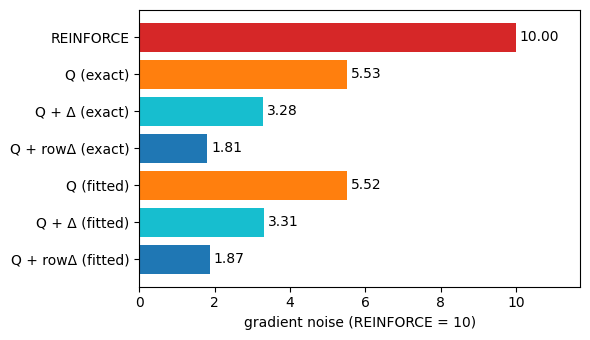

of the noise left by exact Q, Δ removes 41% and the row-wise residual removes 67%.
of the noise left by fitted Q, Δ removes 40% and the row-wise residual removes 66%.


In [9]:
M = 2000
rng = np.random.default_rng(0); total = collections.Counter()
for t in TASKS:
    tree = build_tree(t); f = leaf_rewards(tree, REWARD[t])
    seen = Seen()
    for y in sample(tree, M, rng):
        seen.add(tree.conf[y], float(f[y]))
    total["REINFORCE"] += noise(tree, torch.zeros_like(tree.P), f)                      # no baseline: the 10 reference
    for name, g in (("exact", f), ("fitted", leaf_rewards(tree, seen.f_hat()))):     # g: the reward table the control variate is built from
        Q = Q_table(tree, g)
        total[f"Q ({name})"] += noise(tree, Q, f)
        total[f"Q + Δ ({name})"] += noise(tree, Q + Delta_table(tree, g, Q), f)
        total[f"Q + rowΔ ({name})"] += noise_row(tree, Q, f, increments(tree, Q, g))
    del tree

share = {k: 10 * v / total["REINFORCE"] for k, v in total.items()}
names = list(share)[::-1]
plt.figure(figsize=(6, 3.5))
plt.barh(names, [share[k] for k in names], color=["C0" if "rowΔ" in k else "C9" if "Δ" in k else "C1" if k.startswith("Q") else "C3" for k in names])
for i, k in enumerate(names): plt.text(share[k] + 0.1, i, f"{share[k]:.2f}", va="center")
plt.xlabel("gradient noise (REINFORCE = 10)"); plt.xlim(0, max(share.values()) * 1.17); plt.tight_layout(); plt.show()
for name in ("exact", "fitted"):
    print(f"of the noise left by {name} Q, Δ removes {1 - share[f'Q + Δ ({name})'] / share[f'Q ({name})']:.0%} "
          f"and the row-wise residual removes {1 - share[f'Q + rowΔ ({name})'] / share[f'Q ({name})']:.0%}.")

In [10]:
import sys; sys.path.insert(0, ".."); import torch.nn.functional as F
from baselines import group_weights, relax_weights, Surrogate
GROUP = 4                                                        # episodes per job per step for the group baselines
BASELINES = {"RLOO": GROUP, "GRPO": GROUP, "OTB": GROUP, "RELAX": 1}
SCORED = [k for k, t in enumerate(TEMPLATE) if t is None or FREE_TEXT]     # the positions the tree scores, as in build_tree
DIGIT_POS = [i for i, k in enumerate(SCORED) if TEMPLATE[k] is None]      # which of them write a digit

def decisions(tree, ys):                                         # each leaf as its sequence of decisions: one entry per position, -1 after an early end
    return torch.nn.utils.rnn.pad_sequence([tree.taken[y].nonzero().squeeze(1) for y in ys], batch_first=True, padding_value=-1)

def nodes(tree, ys, T=len(SCORED), A=5):                       # the nodes each leaf went through: their entries (K, T, A), -1 = none; the branch taken (K, T)
    ent = torch.full((len(ys), T, A), -1, device="cuda"); b = torch.zeros(len(ys), T, dtype=torch.long, device="cuda")
    for i, y in enumerate(ys):
        es = tree.passed[y].nonzero().squeeze(1)                 # every branch of every node on the way, in position order
        for t, n in enumerate(tree.node[es].unique()):
            g = es[tree.node[es] == n]; ent[i, t, :len(g)] = g; b[i, t] = (tree.taken[y][g] > 0).nonzero()
    return ent, b

def state(b, T=len(SCORED)):                                   # what RELAX's surrogate knows at each position: the position, and the digits already written
    t = torch.arange(T, device="cuda")
    digits = [F.one_hot(torch.where(t > k, b[:, k, None], 4), 5) for k in DIGIT_POS[:-1]]     # 4 = not written yet
    return torch.cat([F.one_hot(t, T).expand(len(b), T, T), *digits], -1).float()

def baseline_weights(method, tree, ys, f, surrogates, task, gen):     # w with ĝ = w @ Z, like weights(tree, c, f)[ys].mean(0)
    if method == "RELAX":
        ent, b = nodes(tree, ys); st = state(b)
        if task not in surrogates: surrogates[task] = Surrogate(st.shape[-1] + 5).cuda()
        c = surrogates[task]
        w = relax_weights(c, torch.log(tree.P.clamp_min(1e-300))[ent.clamp_min(0)].float(), ent, b, f[ys].float(), len(tree.P), st, gen)
        g = w.detach(); c.fit(w, tree.K)
        return g
    pos = decisions(tree, ys)
    return group_weights(method, f[ys], (pos >= 0).double(), pos, tree.K.diagonal())

The rest of the usual table.  `V` is the state-value baseline (one number per prefix, so a special case of a Q table).
`PSB` is the per-parameter constant baseline $b_i = \\mathbb{E}[f S_i^2] / \\mathbb{E}[S_i^2]$ (Greensmith et al. 2004), from running sums that
never include the episode they correct.  `DM` is the direct method, the exact gradient of the fitted reward table under the
policy: biased, and it samples nothing.  `DR` is doubly robust: the same plus $(f - \\hat f)(y)\\,\\nabla \\log p(y)$, which restores
unbiasedness.  `exact gradient` is the ceiling, the true table's gradient.

In [11]:
MORE = ["V", "PSB", "DR", "DM", "exact gradient"]; MODEL = MORE[1:]     # MODEL: not of the c-table form
NP = sum(p.numel() for p in params)

def table_grad(tree, tab): return ((tree.pb * tab) @ tree.taken).float() @ tree.Z         # the exact gradient of E[tab] under the policy

def model_grad(method, tree, ys, f, seen, psb):
    S = tree.taken[ys].float() @ tree.Z                                                    # the episodes' whole scores grad log p(y)
    if method == "PSB":
        g = ((f[ys].float()[:, None] - psb[0] / psb[1].clamp_min(1e-30)) * S).mean(0)
        psb[0] += (f[ys].float()[:, None] * S ** 2).sum(0); psb[1] += (S ** 2).sum(0)      # updated after use
        return g
    fh = f if method == "exact gradient" else leaf_rewards(tree, seen.f_hat())
    g = table_grad(tree, fh)
    return g + ((f[ys] - fh[ys]).float()[:, None] * S).mean(0) if method == "DR" else g

def model_noise(method, tree, f, seen, psb):                                               # exact Var of one episode
    if method == "DR": return noise(tree, torch.zeros_like(tree.P), f - leaf_rewards(tree, seen.f_hat()))
    if method != "PSB": return np.nan                                                      # DM and the exact gradient sample nothing
    R = (f.float()[:, None] - psb[0] / psb[1].clamp_min(1e-30)) * (tree.taken.float() @ tree.Z); m = tree.pb.float() @ R
    return float(tree.pb.float() @ (R ** 2).sum(1) - (m ** 2).sum())

### Is any of this estimating the right thing?

`REINFORCE` here is the plain estimator, $f\,\nabla \log p(y)$, with no baseline at all.  It sets the 10 on this scale.  A mean-reward baseline
that is known exactly would take that to 9.3, but in a run the constant has to be estimated from the run's own handful of
episodes, and then it costs more than it saves: the same runs with a mean-reward baseline are noisier over the first ten steps
and train worse (0.380 against 0.438 over the first 100 episodes).  The same trap sat in the fitted reward table: giving
untried configurations the mean reward of the tried ones puts a positive constant on exactly the rare failures that carry the
largest scores, and measured along one trajectory it cost the fitted methods 1.3x the plain estimator's noise early and 4.8x
late, where the true table sits at 0.05.  `Seen.f_hat` therefore treats untried as failed, which on 256 configurations with
1 - 3 winners is nearly exact, and that alone moves the fitted methods from below REINFORCE (0.36 - 0.37) to above it.

RLOO subtracts the mean of the other three episodes in its group, and at P(success) around 0.16 most groups are all failures, so
that baseline is mostly noise: one RLOO episode is nearly twice as noisy as one REINFORCE episode.  GRPO divides by the group's
standard deviation and OTB's within-group baseline is not leave-one-out, so neither of them estimates the gradient of E[f] - the
middle column says so.  The group methods also spend four episodes per optimizer step, so at the same episode budget they take a
quarter of the Adam steps.

So REINFORCE is a strong baseline on this task.  The comparison that isolates the residual is `Q` against `Q + Δ` against
`Q + rowΔ`: the same episodes, the same steps, the same reward table.

In [12]:
METHODS = ["REINFORCE", "Q", "Q + Δ", "Q + rowΔ", "Q (exact)", "Q + Δ (exact)", "Q + rowΔ (exact)"]   # "(exact)": the true reward in place of f-hat, a ceiling

tree = build_tree(job); f = leaf_rewards(tree, REWARD[job]); g = ((tree.pb * f) @ tree.taken).float() @ tree.Z     # the true gradient
g2 = float((g.double() ** 2).sum()); rel = lambda m: float(((m - g).double() ** 2).sum()) / g2
rf = noise(tree, torch.zeros_like(tree.P), f)                                    # plain REINFORCE, the = 10 reference
seen = Seen(); rng = np.random.default_rng(0)
for y in sample(tree, 2000, rng): seen.add(tree.conf[y], float(f[y]))            # enough episodes that f-hat has settled

print(f"{job}:" + " " * 18 + "|E[g_hat] - g|^2 / |g|^2                Var of one episode (REINFORCE = 10)")
for m in METHODS:
    c, xi = control_variate(m, tree, seen, f)
    mean = (tree.pb @ weights(tree, c, f)).float() @ tree.Z
    if xi is not None:                                                           # the row-wise residual is subtracted per episode
        mean = mean - tree.pb.float() @ torch.stack([row_correction(tree, xi, y) for y in range(len(tree.conf))]).float()
    v = noise(tree, c, f) if xi is None else noise_row(tree, c, f, xi)
    print(f"  {m:<18} {rel(mean):>8.1e}  exact{' ' * 21}{10 * v / rf:6.2f}")
gen = torch.Generator("cuda").manual_seed(0)
for m, K in BASELINES.items():                                                   # no table, so Monte Carlo over groups of K
    acc, acc2, sur, reps = 0.0, 0.0, {}, 3000 // K
    for _ in range(reps):
        gh = baseline_weights(m, tree, sample(tree, K, rng), f, sur, job, gen).float() @ tree.Z
        acc = acc + gh; acc2 += float((gh.double() ** 2).sum())
    mu = acc / reps; var = acc2 / reps - float((mu.double() ** 2).sum())
    print(f"  {m:<18} {rel(mu):>8.1e}  {reps} groups of {K}, so +-{var / reps / g2:.0e}   {10 * K * var / rf:6.2f}")
S = tree.taken.float() @ tree.Z; w = tree.pb.float(); fh = leaf_rewards(tree, seen.f_hat())   # every answer's whole score, for the rest
for m in MORE:
    if m == "V": c, _ = control_variate(m, tree, seen, f); mean, v = (tree.pb @ weights(tree, c, f)).float() @ tree.Z, noise(tree, c, f)
    elif m == "PSB": R = (f.float()[:, None] - ((w * f.float()) @ S ** 2) / (w @ S ** 2).clamp_min(1e-30)) * S; mean = w @ R; v = float(w @ (R ** 2).sum(1) - (mean ** 2).sum())
    elif m == "DR": mean, v = table_grad(tree, fh) + table_grad(tree, f - fh), noise(tree, torch.zeros_like(tree.P), f - fh)
    else: mean, v = table_grad(tree, f if m == "exact gradient" else fh), 0.0            # nothing is sampled
    print(f"  {m:<18} {rel(mean):>8.1e}  exact{' ' * 21}{10 * v / rf:6.2f}" + ("   (b_i exact)" if m == "PSB" else ""))

lint:                  |E[g_hat] - g|^2 / |g|^2                Var of one episode (REINFORCE = 10)
  REINFORCE           0.0e+00  exact                      10.00
  Q                   0.0e+00  exact                       4.96
  Q + Δ               0.0e+00  exact                       2.69
  Q + rowΔ            1.0e-14  exact                       1.29
  Q (exact)           0.0e+00  exact                       5.06
  Q + Δ (exact)       0.0e+00  exact                       2.69


  Q + rowΔ (exact)    1.1e-14  exact                       1.28


  RLOO                2.0e-03  750 groups of 4, so +-2e-03    16.50


  GRPO                3.5e+00  750 groups of 4, so +-1e-02   115.49


  OTB                 5.3e-02  750 groups of 4, so +-5e-04     5.61


  RELAX               1.2e-03  3000 groups of 1, so +-1e-03    11.50
  V                   0.0e+00  exact                       7.08
  PSB                 1.6e-10  exact                       7.01   (b_i exact)
  DR                  8.5e-15  exact                       0.01
  DM                  1.9e-05  exact                       0.00
  exact gradient      0.0e+00  exact                       0.00


In [13]:
TRAIN = ["port", "digest", "defines", "lint"]
EPISODES, STEPS, LR = 1, 60, 1e-3                              # episodes per job per step (4 per step in total)
SEEDS = list(range(20))        # three seeds cannot rank these: single runs either solve the task or collapse
RUNS = "_rowwise_runs.npz"     # every method's runs are cached here; a method missing from the file is run and added (~20 min per method on one H100)

def train(method, seed, episodes=EPISODES, steps=STEPS, lr=LR, sgd=False):
    reset(); rng = np.random.default_rng(seed); gen = torch.Generator("cuda").manual_seed(seed)
    opt = torch.optim.SGD(params, lr=lr * episodes) if sgd else torch.optim.Adam(params, lr=lr)   # SGD: K averaged episodes get K times the step
    seen = {t: Seen() for t in TRAIN}; surrogates = {}; log = []; dead = False
    psb = {t: [torch.zeros(NP, device="cuda"), torch.zeros(NP, device="cuda")] for t in TRAIN}      # PSB's running sums of f S^2 and S^2
    for step in range(steps + 1):
        grad, success, var, var_rf = 0.0, [], 0.0, 0.0
        for t in (TRAIN if not dead else []):
            tree = build_tree(t); f = leaf_rewards(tree, REWARD[t])
            if not torch.isfinite(tree.pb).all():                    # the step before it sent the weights to NaN: keep the run as a collapse
                print(f"  {method}, seed {seed}: the policy blew up at episode {step * episodes * len(TRAIN)}"); dead = True; del tree; break
            success.append(float(tree.pb @ f)); var_rf += noise(tree, torch.zeros_like(tree.P), f)      # plain REINFORCE, the = 1 reference
            c = xi = None
            if method in BASELINES: var = np.nan                     # no table, so no exact noise
            elif method in MODEL: var += model_noise(method, tree, f, seen[t], psb[t])
            else: c, xi = control_variate(method, tree, seen[t], f); var += noise(tree, c, f) if xi is None else noise_row(tree, c, f, xi)
            if step < steps:
                ys = sample(tree, episodes, rng)
                if method in BASELINES: g = baseline_weights(method, tree, ys, f, surrogates, t, gen).float() @ tree.Z
                elif method in MODEL: g = model_grad(method, tree, ys, f, seen[t], psb[t])
                else:
                    g = weights(tree, c, f)[ys].mean(0).float() @ tree.Z
                    if xi is not None: g = g - torch.stack([row_correction(tree, xi, y) for y in ys]).mean(0).float()
                grad = grad + g / len(TRAIN)
                for y in ys: seen[t].add(tree.conf[y], float(f[y]))
            del tree
        if dead: log.append((step * episodes * len(TRAIN), 0.0, np.nan)); continue
        log.append((step * episodes * len(TRAIN), np.mean(success), var / max(var_rf, 1e-30)))
        if step < steps:
            opt.zero_grad()
            for p, g in zip(params, (-grad).split([p.numel() for p in params])): p.grad = g.view_as(p)
            opt.step()
    return np.array(log)

logs = {}
if os.path.exists(RUNS): z = np.load(RUNS); logs = {str(n): z[f"L{i}"] for i, n in enumerate(z["names"])}
for m in METHODS + MORE + list(BASELINES):                     # the same episode budget: K episodes per job per step, STEPS / K steps
    if m not in logs:
        K = BASELINES.get(m, EPISODES); logs[m] = np.stack([train(m, s, episodes=K, steps=STEPS * EPISODES // K) for s in SEEDS])
        np.savez(RUNS, names=np.array(list(logs)), seeds=np.array(SEEDS), **{f"L{i}": L for i, L in enumerate(logs.values())})
print(f"{RUNS}: {len(logs)} methods x {len(SEEDS)} seeds")

_rowwise_runs.npz: 16 methods x 20 seeds


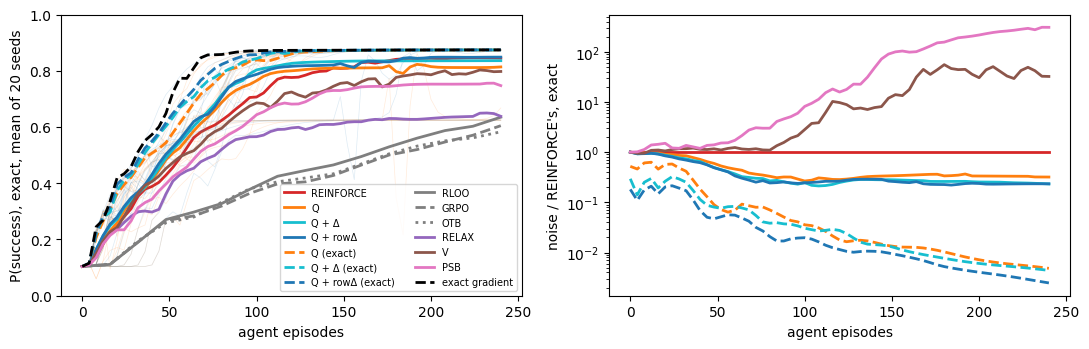

REINFORCE         solves 18/20  collapses  0/20   first 100 episodes 0.438 +- 0.019   final 0.845 +- 0.019   noise over the first 10 steps 1.00
Q                 solves 16/20  collapses  0/20   first 100 episodes 0.471 +- 0.016   final 0.814 +- 0.024   noise over the first 10 steps 0.91
Q + Δ             solves 17/20  collapses  0/20   first 100 episodes 0.487 +- 0.016   final 0.836 +- 0.021   noise over the first 10 steps 0.85
Q + rowΔ          solves 18/20  collapses  0/20   first 100 episodes 0.491 +- 0.017   final 0.848 +- 0.017   noise over the first 10 steps 0.83
Q (exact)         solves 20/20  collapses  0/20   first 100 episodes 0.551 +- 0.014   final 0.874 +- 0.000   noise over the first 10 steps 0.49
Q + Δ (exact)     solves 20/20  collapses  0/20   first 100 episodes 0.570 +- 0.013   final 0.874 +- 0.000   noise over the first 10 steps 0.24
Q + rowΔ (exact)  solves 20/20  collapses  0/20   first 100 episodes 0.586 +- 0.010   final 0.874 +- 0.000   noise over the first 10 ste


paired difference in P(success) over the first 100 episodes:
  Q + Δ              - Q                  +0.015 +- 0.010   p 0.153   12/20 seeds
  Q + rowΔ           - Q                  +0.019 +- 0.010   p 0.060   14/20 seeds
  Q + rowΔ           - Q + Δ              +0.004 +- 0.006   p 0.551   11/20 seeds
  Q                  - REINFORCE          +0.033 +- 0.018   p 0.079   14/20 seeds
  Q + rowΔ           - V                  +0.059 +- 0.011   p 0.000   17/20 seeds
  Q + rowΔ           - PSB                +0.098 +- 0.024   p 0.001   19/20 seeds
  Q + rowΔ           - DR                 -0.007 +- 0.005   p 0.189   5/20 seeds
  Q + rowΔ           - DM                 -0.034 +- 0.011   p 0.005   4/20 seeds
  Q + Δ (exact)      - Q (exact)          +0.019 +- 0.016   p 0.252   15/20 seeds
  Q + rowΔ (exact)   - Q (exact)          +0.035 +- 0.017   p 0.047   15/20 seeds
  Q + rowΔ (exact)   - Q + Δ (exact)      +0.016 +- 0.009   p 0.085   13/20 seeds


In [14]:
style = {"REINFORCE": ("C3", "-"), "Q": ("C1", "-"), "Q + Δ": ("C9", "-"), "Q + rowΔ": ("C0", "-"),
         "Q (exact)": ("C1", "--"), "Q + Δ (exact)": ("C9", "--"), "Q + rowΔ (exact)": ("C0", "--"),
         "RLOO": ("C7", "-"), "GRPO": ("C7", "--"), "OTB": ("C7", ":"), "RELAX": ("C4", "-"),
         "V": ("C5", "-"), "PSB": ("C6", "-"), "DR": ("C2", "-"), "DM": ("C2", "--"), "exact gradient": ("k", "--")}
HIDE = {"DR", "DM"}                                            # in the table below, not in the figure: their full-tree model term is free only on a tree this small
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for m, L in logs.items():                                      # a log row: (episodes so far, P(success), noise / REINFORCE's)
    if m in HIDE: continue
    col, ls = style.get(m, ("k", ":")); episodes = L[0, :, 0]
    ax[0].plot(episodes, L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=m)      # REINFORCE: no baseline
    if m in ("Q", "Q + rowΔ"):                                 # the individual runs of the pair the residual is meant to separate
        for run in L: ax[0].plot(episodes, run[:, 1], color=col, ls=ls, lw=0.5, alpha=0.15)
    if np.isfinite(L[:, :, 2]).all(): ax[1].plot(episodes, np.exp(np.log(L[:, :, 2]).mean(0)), color=col, ls=ls, lw=2, label=m)
ax[0].set(xlabel="agent episodes", ylabel=f"P(success), exact, mean of {len(SEEDS)} seeds", ylim=(0, 1)); ax[0].legend(fontsize=7, ncol=2)
ax[1].set(xlabel="agent episodes", ylabel="noise / REINFORCE's, exact", yscale="log")
plt.tight_layout(); plt.show()

m100 = lambda L: L[:, L[0, :, 0] <= 100, 1].mean(1)            # one number per run: P(success) over the first 100 episodes
for m, L in logs.items():
    mean, fin = m100(L), L[:, -1, 1]
    print(f"{m:<17} solves {int((L[:, :, 1] >= 0.8).any(1).sum()):>2}/{len(L)}  collapses {int((fin < 0.05).sum()):>2}/{len(L)}   "
          f"first 100 episodes {mean.mean():.3f} +- {mean.std(ddof=1) / len(mean) ** 0.5:.3f}   final {fin.mean():.3f} +- {fin.std(ddof=1) / len(fin) ** 0.5:.3f}"
          f"   noise over the first 10 steps {np.exp(np.log(L[:, :10, 2]).mean()):.2f}")

from scipy import stats                                        # paired over the seeds: every method saw the same 20 seeds
print(f"\npaired difference in P(success) over the first 100 episodes:")
for a, b in [("Q + Δ", "Q"), ("Q + rowΔ", "Q"), ("Q + rowΔ", "Q + Δ"), ("Q", "REINFORCE"), ("Q + rowΔ", "V"), ("Q + rowΔ", "PSB"),
             ("Q + rowΔ", "DR"), ("Q + rowΔ", "DM"),
             ("Q + Δ (exact)", "Q (exact)"), ("Q + rowΔ (exact)", "Q (exact)"), ("Q + rowΔ (exact)", "Q + Δ (exact)")]:
    d = m100(logs[a]) - m100(logs[b])
    print(f"  {a:<18} - {b:<18} {d.mean():+.3f} +- {d.std(ddof=1) / len(d) ** 0.5:.3f}   "
          f"p {stats.ttest_rel(m100(logs[a]), m100(logs[b])).pvalue:.3f}   {int((d > 0).sum())}/{len(d)} seeds")

### The same comparison under plain SGD

Adam normalises every parameter's step, so a step's size hardly depends on the gradient's scale or its noise: plain REINFORCE's
zero gradients on failed episodes cost it nothing, and the group methods' four-episode steps make their path four times shorter.
Plain SGD lets the estimator's variance reach the curve directly (expected progress per step is
$\\mathrm{lr}\\,\\|g\\|^2 - \\mathrm{lr}^2 (\\|g\\|^2 + \\mathrm{Var}) / 2$), and the group methods get four times the step for their four averaged episodes, so
every method takes one step's worth per episode.  The two learning rates come from a sweep: 0.06 is the largest at which the
exact gradient still trains at full speed (0.1 slows it, 0.3 kills it), and 0.03 is half of that, where every method is stable.

_rowwise_runs_sgd.npz: 28 (method, lr) pairs x 20 seeds


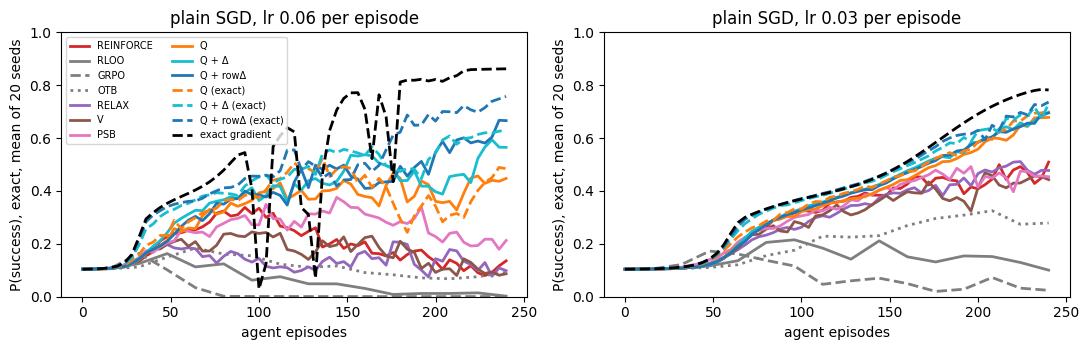


lr 0.06
  REINFORCE         solves  0/20  collapses 15/20   mean over the run 0.193 +- 0.015   final 0.136 +- 0.052
  RLOO              solves  0/20  collapses 20/20   mean over the run 0.066 +- 0.006   final 0.002 +- 0.001
  GRPO              solves  0/20  collapses 20/20   mean over the run 0.032 +- 0.002   final 0.001 +- 0.000
  OTB               solves  0/20  collapses 11/20   mean over the run 0.113 +- 0.010   final 0.092 +- 0.029
  RELAX             solves  0/20  collapses 16/20   mean over the run 0.138 +- 0.019   final 0.099 +- 0.053
  V                 solves  0/20  collapses 17/20   mean over the run 0.165 +- 0.018   final 0.087 +- 0.047
  PSB               solves  0/20  collapses 13/20   mean over the run 0.243 +- 0.022   final 0.213 +- 0.068
  Q                 solves  9/20  collapses  9/20   mean over the run 0.327 +- 0.027   final 0.447 +- 0.093
  Q + Δ             solves  9/20  collapses  4/20   mean over the run 0.371 +- 0.017   final 0.565 +- 0.076
  Q + rowΔ         

In [15]:
SGD_LR = [0.06, 0.03]                                        # per episode; from a sweep over 0.03 - 10 on REINFORCE, Q + rowΔ and the exact gradient
SGD_METHODS = ["REINFORCE", "RLOO", "GRPO", "OTB", "RELAX", "V", "PSB", "Q", "Q + Δ", "Q + rowΔ", "Q (exact)", "Q + Δ (exact)", "Q + rowΔ (exact)", "exact gradient"]
RUNS_SGD = "_rowwise_runs_sgd.npz"                          # cached like the Adam runs; a missing (method, lr) is run and added
logs_sgd = {}
if os.path.exists(RUNS_SGD): z = np.load(RUNS_SGD); logs_sgd = {str(n): z[f"L{i}"] for i, n in enumerate(z["names"])}
for lr in SGD_LR:
    for m in SGD_METHODS:
        if f"{m} @ {lr}" not in logs_sgd:
            K = BASELINES.get(m, EPISODES); logs_sgd[f"{m} @ {lr}"] = np.stack([train(m, s, episodes=K, steps=STEPS * EPISODES // K, lr=lr, sgd=True) for s in SEEDS])
            np.savez(RUNS_SGD, names=np.array(list(logs_sgd)), seeds=np.array(SEEDS), **{f"L{i}": L for i, L in enumerate(logs_sgd.values())})
print(f"{RUNS_SGD}: {len(logs_sgd)} (method, lr) pairs x {len(SEEDS)} seeds")

fig, ax = plt.subplots(1, len(SGD_LR), figsize=(5.5 * len(SGD_LR), 3.6), squeeze=False)
for a, lr in zip(ax[0], SGD_LR):
    for m in SGD_METHODS:
        L = logs_sgd[f"{m} @ {lr}"]; col, ls = style.get(m, ("k", ":"))
        a.plot(L[0, :, 0], L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=m)
    a.set(xlabel="agent episodes", ylabel=f"P(success), exact, mean of {len(SEEDS)} seeds", ylim=(0, 1), title=f"plain SGD, lr {lr} per episode")
ax[0][0].legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

for lr in SGD_LR:
    print(f"\nlr {lr}")
    for m in SGD_METHODS:
        L = logs_sgd[f"{m} @ {lr}"]; mean, fin = L[:, :, 1].mean(1), L[:, -1, 1]             # SGD is slow early: the whole run, and where it ends
        print(f"  {m:<17} solves {int((L[:, :, 1] >= 0.8).any(1).sum()):>2}/{len(L)}  collapses {int((fin < 0.05).sum()):>2}/{len(L)}   "
              f"mean over the run {mean.mean():.3f} +- {mean.std(ddof=1) / len(mean) ** 0.5:.3f}   final {fin.mean():.3f} +- {fin.std(ddof=1) / len(fin) ** 0.5:.3f}")
    for a, b in [("Q", "REINFORCE"), ("Q + rowΔ", "REINFORCE"), ("Q + rowΔ", "Q"), ("Q + rowΔ", "Q + Δ"), ("Q + rowΔ", "V"), ("Q + rowΔ", "PSB"),
                 ("Q + rowΔ", "RELAX"), ("RLOO", "REINFORCE"), ("Q + rowΔ (exact)", "Q (exact)")]:
        x, y = logs_sgd[f"{a} @ {lr}"][:, -1, 1], logs_sgd[f"{b} @ {lr}"][:, -1, 1]; d = x - y               # paired on the final policy
        print(f"    {a:<18} - {b:<18} final {d.mean():+.3f} +- {d.std(ddof=1) / len(d) ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.4f}   {int((d > 0).sum())}/{len(d)} seeds")

### What the 20 seeds say

**Variance.**  Pooled over the ten tasks the row-wise residual removes 67% of the noise the exact Q table leaves, against 41%
for the scalar Δ, and 66% against 40% for a table fitted from the run's own episodes.  On `lint`, with plain REINFORCE at 10:
Q 5.06, Q + Δ 2.69, Q + rowΔ 1.28.  It costs the same two tree passes as the scalar Δ, and no linear solve.

**Training, fitted table.**  Over the first 100 episodes: REINFORCE 0.438, Q 0.471, Q + Δ 0.487, Q + rowΔ 0.491.  Paired over
the seeds, Q + rowΔ − REINFORCE is +0.052 +- 0.016 (p 0.004, 16 of 20) and Q + rowΔ − Q is +0.019 +- 0.010 (p 0.06); the
row-wise and scalar residuals are not separated (+0.004 +- 0.006).  Final policies 0.845 / 0.814 / 0.836 / 0.848.  Two things
limit the fitted gain: the first ten steps run at 0.83 - 0.91 of REINFORCE's noise, not the 0.33 the bar chart promises, because
f-hat is built from a few dozen episodes; and late in a run the table's error on the winning answer (n / (n + 1) after n visits)
is what remains, not the control variate.

**Training, true table.**  0.551 -> 0.570 -> 0.586 for Q, Q + Δ, Q + rowΔ at noise 0.49 / 0.24 / 0.17; row-wise minus Q is
+0.035 +- 0.017 (p 0.047, 15 of 20 seeds) and row-wise minus scalar Δ is +0.016 +- 0.009 (p 0.085).  All twenty runs solve
the task.

**Under plain SGD the control variate decides which learning rate is usable.**  At lr 0.03 every estimator is stable and
the final policy is REINFORCE 0.509, Q 0.678, Q + Δ 0.696, Q + rowΔ 0.696 (Q + rowΔ − REINFORCE +0.186 +- 0.043, p 3e-4,
17 of 20 seeds); the residuals are not separated from Q there (+0.017), and with the true table it is 0.704 / 0.730 / 0.736
(p 0.056).  At lr 0.06, where the exact gradient is fastest (0.862) but already overshoots, plain REINFORCE collapses in 15 of
20 runs and RLOO in all 20, and the ladder is the whole story: Q 0.447 (9 collapses), Q + Δ 0.565 (4), Q + rowΔ 0.666 (3, and
14 runs solve the task); with the true table 0.484 / 0.629 / 0.758 (7 / 5 / 2 collapses), row-wise minus Q +0.273 +- 0.085
(p 0.004).  Q + rowΔ − REINFORCE is +0.530 +- 0.102 (p 1e-4, 18 of 20).  Adam hid this: its normalised steps let plain
REINFORCE skip its zero gradients for free, and there the same estimators differ by 0.05.  The other baselines do no better
under SGD: at lr 0.03 V 0.443, PSB 0.454 and RELAX 0.477 end below plain REINFORCE, OTB at 0.279 and GRPO at 0.024 (19 of 20
collapse); at lr 0.06 all five collapse in 11 - 20 of 20 runs.  Q + rowΔ is ahead of each of them by +0.22 - 0.25 at lr 0.03
and +0.45 - 0.58 at lr 0.06 (p <= 0.0013).

**The rest of the table.**  `V` (0.432) and `PSB` (0.393) sit at or below plain REINFORCE: a coarser baseline than Q buys
nothing here, and the per-parameter constant, estimated from running sums, is noisier than none over the first ten steps
(1.24).  Both climb to 30 - 300x the plain estimator's noise late in the run (right panel): a baseline averaged over the whole
history goes stale once the policy has moved, exactly as the mean-reward baseline did for REINFORCE.  `DR` (0.498; DR and DM are in the table, not drawn) ties Q + rowΔ (−0.007 +- 0.005, p 0.19): the same f-hat, used as a regression baseline instead of a
control variate, ends in the same place.  The biased direct method `DM` is ahead of both at 0.525 (+0.034 +- 0.011 over
Q + rowΔ, p 0.005, 16 of 20 seeds against DR), and the exact gradient reaches 0.619: with a 256-entry lookup table the
model-based bias is small and the sampling noise it avoids is not.  Even with the true table the row-wise estimator's own
sampling noise still costs 0.033 against the exact gradient (p 0.005).

So the residual is a clear variance result, and a training result in proportion to how good the reward table is: with a
fitted table Q + rowΔ is the best unbiased estimator here, tied with DR and +0.05 over plain REINFORCE, and the biased DM is
better still; with the true table the stack is worth +0.15.  That is the ordering `LIVE_FREE.md` found on the free-text
queue, where the scalar Δ is a null (0.94 of Q) and the row-wise residual wins by a wider margin.

### Run until the curve is flat, lr 0.06

The lr 0.06 panel above stops at 240 episodes with every mean curve still moving.  Here the same runs go on until they are
flat: a run stops once the mean P(success) over its last 40 steps has moved by less than 0.01 against the 40 steps before
(checked every 10 steps after step 120), or at step 400.  A collapsed run goes flat at 0 and stops by the same rule.  Five
seeds, `_sgd_long/worker.py`, one process per GPU; the first 60 steps of every run reproduce the runs above bit for bit.


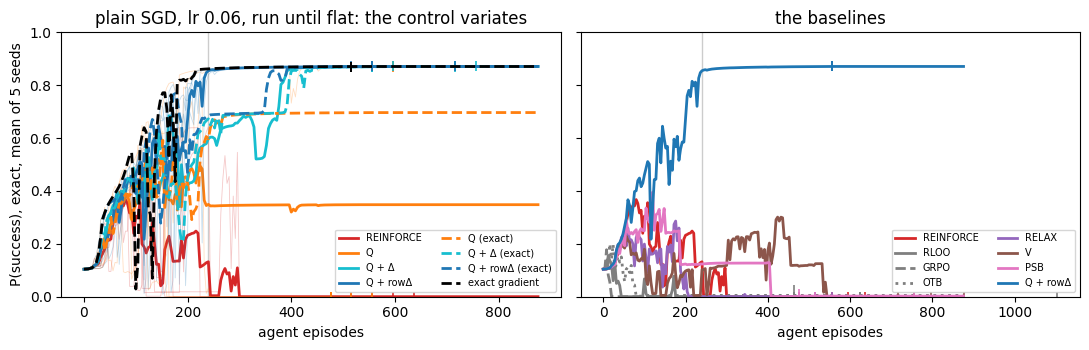

lr 0.06, until flat  stopped at (steps)  solves  collapses           final  episodes to 0.8 (solving runs)
  REINFORCE                     119-159       0          5    0.000 +-0.000                               -
  RLOO                            29-69       0          5    0.000 +-0.000                               -
  GRPO                            29-29       0          5    0.000 +-0.000                               -
  OTB                             29-39       0          5    0.005 +-0.005                               -
  RELAX                         119-139       0          5    0.000 +-0.000                               -
  V                             119-219       0          5    0.000 +-0.000                               -
  PSB                           119-189       0          5    0.002 +-0.002                               -
  Q                             119-139       2          3    0.348 +-0.213                  182  (164-200)
  Q + Δ                      

In [ ]:
import glob
LONG = "_sgd_long"                                             # lr 0.06 run until flat: `python _sgd_long/worker.py <gpu>`, one process per GPU, seeds 0-4
MIN_STEPS, MAX_STEPS, WIN, TOL = 120, 400, 40, 0.01            # a run stops when the mean P(success) over the last 40 steps moved < 0.01 against the 40 before (checked every 10 steps), or at 400
tag = lambda m: m.replace(" ", "").replace("+", "p").replace("(", "").replace(")", "")
long = {m: [np.load(f) for f in sorted(glob.glob(f"{LONG}/{tag(m)}_s[0-4].npy"))] for m in SGD_METHODS}
carry = lambda L, n: np.concatenate([L[:, 1], np.full(n - len(L), L[-1, 1])])     # a stopped run keeps its last value in the mean curve: it stopped because it was flat

n = max(len(L) for Ls in long.values() for L in Ls); ep = 4 * np.arange(n)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for a, ms in zip(ax, (["REINFORCE", "Q", "Q + Δ", "Q + rowΔ", "Q (exact)", "Q + Δ (exact)", "Q + rowΔ (exact)", "exact gradient"], ["REINFORCE", "RLOO", "GRPO", "OTB", "RELAX", "V", "PSB", "Q + rowΔ"])):
    for m in ms:
        col, ls = style[m]; a.plot(ep, np.stack([carry(L, n) for L in long[m]]).mean(0), color=col, ls=ls, lw=2, label=m)
        if a is ax[0] and m in ("REINFORCE", "Q", "Q + rowΔ"):
            for L in long[m]: a.plot(L[:, 0], L[:, 1], color=col, ls=ls, lw=0.6, alpha=0.25)                  # the single runs
        for L in long[m]: a.plot([L[-1, 0]], [L[-1, 1]], color=col, marker="|", ms=7, mew=1.2)                  # where each run stopped
    a.set(xlabel="agent episodes", ylim=(0, 1)); a.legend(fontsize=7, ncol=2); a.axvline(4 * STEPS, color="0.8", lw=1, zorder=0)   # the budget above
ax[0].set(ylabel="P(success), exact, mean of 5 seeds", title="plain SGD, lr 0.06, run until flat: the control variates"); ax[1].set(title="the baselines")
plt.tight_layout(); plt.show()

print(f"{'lr 0.06, until flat':<19}{'stopped at (steps)':>20}{'solves':>8}{'collapses':>11}{'final':>16}{'episodes to 0.8 (solving runs)':>32}")
for m in SGD_METHODS:
    Ls = long[m]; fin = np.array([L[-1, 1] for L in Ls]); steps = [len(L) - 1 for L in Ls]
    hit = [int(L[np.argmax(L[:, 1] >= 0.8), 0]) for L in Ls if (L[:, 1] >= 0.8).any()]                      # the first step at or above 0.8
    print(f"  {m:<17}{f'{min(steps)}-{max(steps)}':>20}{len(hit):>8}{int((fin < 0.05).sum()):>11}{fin.mean():>9.3f} +-{fin.std(ddof=1) / len(fin) ** 0.5:.3f}"
          f"{(f'{np.mean(hit):.0f}  ({min(hit)}-{max(hit)})' if hit else '-'):>32}")
for a, b in [("Q", "REINFORCE"), ("Q + rowΔ", "REINFORCE"), ("Q + rowΔ", "Q"), ("Q + rowΔ", "Q + Δ"), ("Q + Δ", "Q"), ("Q + rowΔ (exact)", "Q (exact)"), ("Q + rowΔ (exact)", "Q + Δ (exact)")]:
    x, y = (np.array([L[-1, 1] for L in long[m]]) for m in (a, b)); d = x - y
    print(f"    {a:<18} - {b:<18} final {d.mean():+.3f} +- {d.std(ddof=1) / len(d) ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.3f}   {int((d > 0).sum())}/{len(d)} seeds")


**At the end there is nothing between the two residuals.**  Q + Δ and Q + rowΔ reach 0.871 on all five seeds, the plateau
of the exact gradient, so the lr 0.06 gap between them at 240 episodes (0.565 against 0.666) was a gap in speed, not in where
they end: Q + rowΔ passes 0.8 after 172-220 episodes on every seed (mean 203), Q + Δ after 188-376 (mean 270), the exact
gradient after 180.  Over the first 240 episodes the means are 0.457, 0.396 and 0.348 for rowΔ, Δ and Q, the ranking of the
20 seeds above.

What the longer run changes is the ladder below.  Plain Q is a coin flip: two runs reach 0.871 and three collapse to 0
(final 0.348 +- 0.213).  Plain REINFORCE collapses in all five runs, and so does every baseline (RLOO, GRPO, OTB, RELAX, V,
PSB); none of them ever recovers, and the REINFORCE run that stood at 0.64 after 240 episodes ended at 0.  With the true
table the picture is one rung up: Q (exact) loses one run of five, the two residuals none.

So at lr 0.06 the control variate decides whether a run converges, not where it converges to, and the residual on top of Q
is what turns a coin flip into five of five.  The scalar and row-wise residuals both do that here; the row-wise one is faster.


### 700 episodes at lr 0.03 and 0.05

The same runs at a fixed budget of 700 episodes (175 steps; 43 four-episode steps for the group baselines), at the two lower
rates, seeds 0-4.  The first 60 steps at 0.03 reproduce the 20-seed runs above bit for bit.


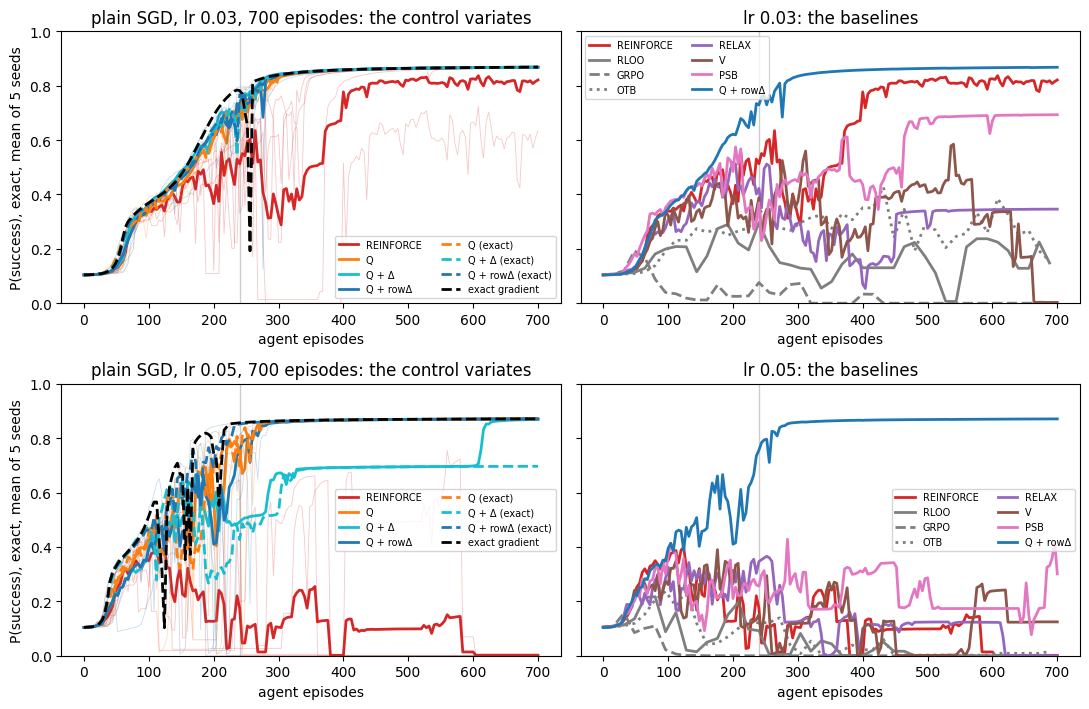

lr 0.03, 700 episodes     solves  collapses   mean over the run           final  episodes to 0.8 (solving runs)
  REINFORCE               4          0        0.570 +-0.047    0.821 +-0.046                  357  (340-396)
  RLOO                    0          3        0.162 +-0.045    0.148 +-0.091                               -
  GRPO                    0          5        0.032 +-0.007    0.000 +-0.000                               -
  OTB                     0          3        0.257 +-0.035    0.156 +-0.132                               -
  RELAX                   2          3        0.296 +-0.103    0.346 +-0.212                  400  (368-432)
  V                       4          5        0.306 +-0.065    0.003 +-0.001                  466  (348-600)
  PSB                     4          1        0.488 +-0.103    0.693 +-0.173                  357  (280-464)
  Q                       5          0        0.685 +-0.003    0.868 +-0.000                  281  (256-296)
  Q + Δ         

In [ ]:
import glob
EP700 = {0.03: "_sgd_long/ep700_lr0.03", 0.05: "_sgd_long/ep700_lr0.05"}     # `SGD_FIXED_STEPS=175 SGD_JOBS="0.03:<dir>,0.05:<dir>" python _sgd_long/worker.py <gpu>`: 175 steps = 700 episodes, seeds 0-4
tag = lambda m: m.replace(" ", "").replace("+", "p").replace("(", "").replace(")", "")
ep700 = {lr: {m: np.stack([np.load(f) for f in sorted(glob.glob(f"{d}/{tag(m)}_s[0-4].npy"))]) for m in SGD_METHODS} for lr, d in EP700.items()}

fig, ax = plt.subplots(len(EP700), 2, figsize=(11, 3.6 * len(EP700)), sharey=True, squeeze=False)
for row, (lr, runs) in zip(ax, ep700.items()):
    for a, ms in zip(row, (["REINFORCE", "Q", "Q + Δ", "Q + rowΔ", "Q (exact)", "Q + Δ (exact)", "Q + rowΔ (exact)", "exact gradient"], ["REINFORCE", "RLOO", "GRPO", "OTB", "RELAX", "V", "PSB", "Q + rowΔ"])):
        for m in ms:
            col, ls = style[m]; L = runs[m]; a.plot(L[0, :, 0], L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=m)
            if a is row[0] and m in ("REINFORCE", "Q", "Q + rowΔ"):
                for run in L: a.plot(run[:, 0], run[:, 1], color=col, ls=ls, lw=0.6, alpha=0.25)                 # the single runs
        a.set(xlabel="agent episodes", ylim=(0, 1)); a.legend(fontsize=7, ncol=2); a.axvline(4 * STEPS, color="0.8", lw=1, zorder=0)   # the budget above
    row[0].set(ylabel="P(success), exact, mean of 5 seeds", title=f"plain SGD, lr {lr}, 700 episodes: the control variates"); row[1].set(title=f"lr {lr}: the baselines")
plt.tight_layout(); plt.show()

for lr, runs in ep700.items():
    print(f"lr {lr}, 700 episodes{'':<3}{'solves':>8}{'collapses':>11}{'mean over the run':>20}{'final':>16}{'episodes to 0.8 (solving runs)':>32}")
    for m in SGD_METHODS:
        L = runs[m]; fin = L[:, -1, 1]; mean = L[:, :, 1].mean(1)
        hit = [int(run[np.argmax(run[:, 1] >= 0.8), 0]) for run in L if (run[:, 1] >= 0.8).any()]
        print(f"  {m:<17}{len(hit):>8}{int((fin < 0.05).sum()):>11}{mean.mean():>13.3f} +-{mean.std(ddof=1) / len(mean) ** 0.5:.3f}{fin.mean():>9.3f} +-{fin.std(ddof=1) / len(fin) ** 0.5:.3f}"
              f"{(f'{np.mean(hit):.0f}  ({min(hit)}-{max(hit)})' if hit else '-'):>32}")
    for a, b in [("Q", "REINFORCE"), ("Q + rowΔ", "REINFORCE"), ("Q + rowΔ", "Q"), ("Q + rowΔ", "Q + Δ"), ("Q + Δ", "Q"), ("Q + rowΔ (exact)", "Q (exact)"), ("Q + rowΔ (exact)", "Q + Δ (exact)")]:
        x, y = runs[a][:, -1, 1], runs[b][:, -1, 1]; d = x - y
        print(f"    {a:<18} - {b:<18} final {d.mean():+.3f} +- {d.std(ddof=1) / len(d) ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.3f}   {int((d > 0).sum())}/{len(d)} seeds")
    print()


**lr 0.03: everyone with a table converges, and the residuals add nothing.**  Q, Q + Δ and Q + rowΔ all end at 0.868 on
every seed, the exact gradient's plateau, and pass 0.8 after 264-281 episodes against the exact gradient's 260.  Plain
REINFORCE gets there too, later: 357 episodes to 0.8, four of five at 0.868, the fifth at 0.64.  At this rate the noise only
costs time.  Of the baselines only PSB keeps up (four of five); V passes 0.8 on four seeds and then collapses on all five, its
running-average baseline stale once the policy has moved; RELAX solves two and collapses three; RLOO, GRPO and OTB stay low.

**lr 0.05: the table decides, the residual does not.**  REINFORCE and every baseline collapse (REINFORCE five of five, final
0.001).  Q converges on all five seeds (0.871, 234 episodes to 0.8) and so does Q + rowΔ (231); the two are not separated
(mean over the run 0.713 against 0.701).  The scalar Δ is the odd one: all five runs end at 0.87, but two of them fell to 0.00
at 192-220 episodes and climbed back, so its mean over the run is 0.598 +- 0.100, and with the true table one Q + Δ (exact) run
stays down (0.697 +- 0.174) while Q + rowΔ (exact) runs at 0.741, next to the exact gradient's 0.743.  The climb back says
something about the estimator: a failed episode still carries a signal through the table, −c on the path it took and +P c on
the siblings, so a run with a table can come back from P(success) ≈ 0.  Plain REINFORCE's failed episodes are zeros, and it
cannot.

With lr 0.06 above the three rates line up: at 0.03 nothing separates the estimators but speed; at 0.05 the table separates
them from REINFORCE and the baselines; at 0.06 the residual separates Q + Δ and Q + rowΔ (five of five) from Q (two of five).
The control variate buys the largest learning rate at which a run still converges.  The row-wise residual is the steadier of
the two: tied with Q at 0.03 and 0.05 and ahead at 0.06, where the scalar Δ dips at 0.05.


### A warm start: 400 episodes at lr 0.03 and 0.06

The mean baselines had nothing to subtract while nine episodes in ten scored 0.  Here every method starts a seed from the same
supervised warm start: `_sgd_long/warm.py` takes a few cross-entropy steps on known-good configurations (one per training task
per step, the seed's rng picks which; Adam 5e-4) and stops as soon as the exact mean P(success) over the training tasks reaches
0.35 (7-14 steps; the five seeds start at 0.352-0.373).  The LoRA weights are saved and every method loads them, so within a seed
all curves leave the same point.  f-hat still starts empty.  Plain SGD, 100 steps = 400 episodes, seeds 0-4; at 0.06 the six methods that carry the ordering (REINFORCE, V, PSB, Q, Q + Δ,
Q + rowΔ) have seeds 0-19 (the legend and the table give n).


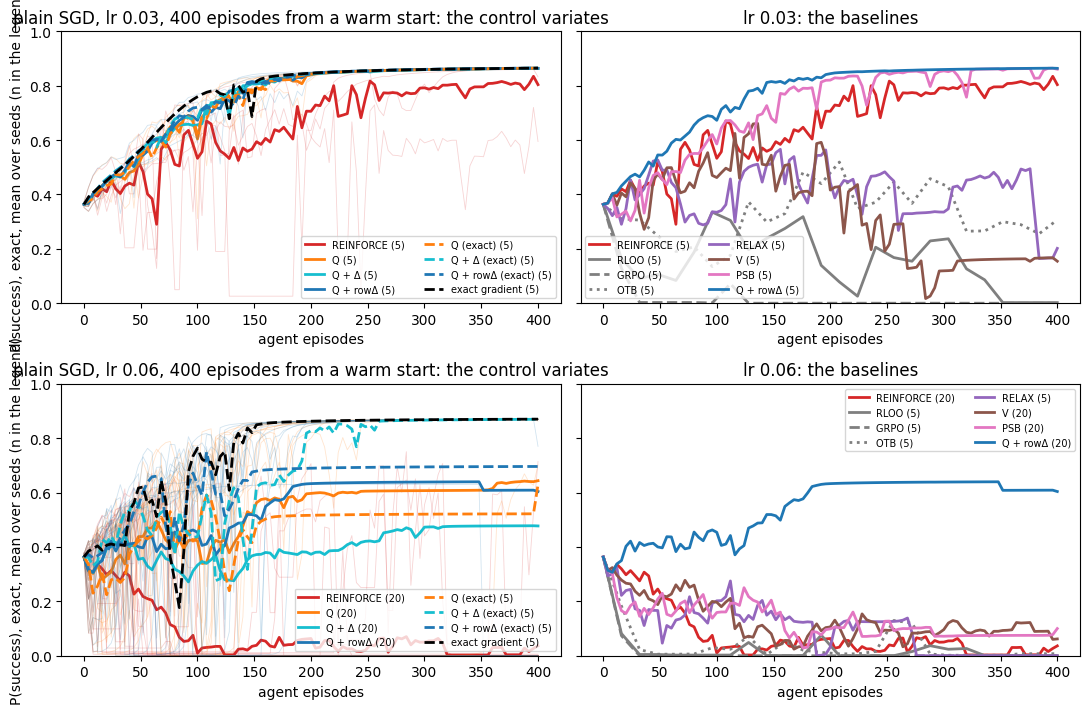

lr 0.03, warm start, 400 episodes    seeds  solves  collapses   mean over the run           final  episodes to 0.8 (solving runs)
  REINFORCE             5       5          0        0.657 +-0.031    0.804 +-0.053                  183  (132-240)
  RLOO                  5       0          5        0.159 +-0.053    0.002 +-0.001                               -
  GRPO                  5       0          5        0.022 +-0.003    0.000 +-0.000                               -
  OTB                   5       0          2        0.326 +-0.066    0.307 +-0.145                               -
  RELAX                 5       4          3        0.407 +-0.066    0.202 +-0.162                  272  (208-384)
  V                     5       3          4        0.334 +-0.072    0.154 +-0.154                  243  (172-336)
  PSB                   5       5          0        0.712 +-0.007    0.861 +-0.004                  170  (144-200)
  Q                     5       5          0        0.756 +-0.009

In [ ]:
import glob
WARM = {0.03: "_sgd_long/warm_lr0.03", 0.06: "_sgd_long/warm_lr0.06"}       # `SGD_FIXED_STEPS=100 SGD_WARM=_sgd_long/warm SGD_JOBS="0.03:<dir>,0.06:<dir>" python _sgd_long/worker.py <gpu>`: 100 steps = 400 episodes from the seed's warm start
tag = lambda m: m.replace(" ", "").replace("+", "p").replace("(", "").replace(")", "")                    # warm.py: a few supervised steps on known-good configurations until P(success) = 0.35, one file per seed, shared by every method
warm = {lr: {m: np.stack([np.load(f) for f in sorted(glob.glob(f"{d}/{tag(m)}_s*.npy"))]) for m in SGD_METHODS} for lr, d in WARM.items()}   # seeds 0-4 everywhere; 0-19 for six methods at 0.06

fig, ax = plt.subplots(len(WARM), 2, figsize=(11, 3.6 * len(WARM)), sharey=True, squeeze=False)
for row, (lr, runs) in zip(ax, warm.items()):
    for a, ms in zip(row, (["REINFORCE", "Q", "Q + Δ", "Q + rowΔ", "Q (exact)", "Q + Δ (exact)", "Q + rowΔ (exact)", "exact gradient"], ["REINFORCE", "RLOO", "GRPO", "OTB", "RELAX", "V", "PSB", "Q + rowΔ"])):
        for m in ms:
            col, ls = style[m]; L = runs[m]; a.plot(L[0, :, 0], L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=f"{m} ({len(L)})")
            if a is row[0] and m in ("REINFORCE", "Q", "Q + rowΔ"):
                for run in L: a.plot(run[:, 0], run[:, 1], color=col, ls=ls, lw=0.6, alpha=0.2)                  # the single runs
        a.set(xlabel="agent episodes", ylim=(0, 1)); a.legend(fontsize=7, ncol=2)
    row[0].set(ylabel="P(success), exact, mean over seeds (n in the legend)", title=f"plain SGD, lr {lr}, 400 episodes from a warm start: the control variates"); row[1].set(title=f"lr {lr}: the baselines")
plt.tight_layout(); plt.show()

for lr, runs in warm.items():
    print(f"lr {lr}, warm start, 400 episodes{'':<3}{'seeds':>6}{'solves':>8}{'collapses':>11}{'mean over the run':>20}{'final':>16}{'episodes to 0.8 (solving runs)':>32}")
    for m in SGD_METHODS:
        L = runs[m]; n = len(L); fin = L[:, -1, 1]; mean = L[:, :, 1].mean(1)
        hit = [int(run[np.argmax(run[:, 1] >= 0.8), 0]) for run in L if (run[:, 1] >= 0.8).any()]
        print(f"  {m:<17}{n:>6}{len(hit):>8}{int((fin < 0.05).sum()):>11}{mean.mean():>13.3f} +-{mean.std(ddof=1) / n ** 0.5:.3f}{fin.mean():>9.3f} +-{fin.std(ddof=1) / n ** 0.5:.3f}"
              f"{(f'{np.mean(hit):.0f}  ({min(hit)}-{max(hit)})' if hit else '-'):>32}")
    for a, b in [("Q + rowΔ", "Q"), ("Q + rowΔ", "Q + Δ"), ("Q + Δ", "Q"), ("Q", "PSB"), ("PSB", "REINFORCE"), ("V", "REINFORCE"), ("Q", "REINFORCE"), ("Q + rowΔ", "REINFORCE")]:
        n = min(len(runs[a]), len(runs[b])); x, y = runs[a][:n, :, 1].mean(1), runs[b][:n, :, 1].mean(1); d = x - y       # paired on the seeds both have, mean over the run
        print(f"    {a:<10} - {b:<10} mean over the run {d.mean():+.3f} +- {d.std(ddof=1) / n ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.3f}   {int((d > 0).sum())}/{n} seeds")
    print()


**lr 0.03: a mean baseline is now worth something, and the table is worth more.**  From 0.36 every method with a table
reaches 0.864 on all five seeds, 137-148 episodes to 0.8 (the exact gradient: 126), and PSB, the per-parameter constant
baseline, converges too (five of five, 170 episodes, mean over the run 0.712).  Plain REINFORCE passes 0.8 on all five seeds but
later (183) and ends lower (0.804, one run at 0.59).  Mean over the run: Q + rowΔ 0.761 ≈ Q + Δ 0.758 ≈ Q 0.756 > PSB 0.712 >
REINFORCE 0.657 > RELAX 0.407 > V 0.334 > OTB 0.326 > RLOO 0.159 > GRPO 0.022.  The residuals are still not separated from Q at
this rate.

**lr 0.06, five seeds: the order the residual is meant to produce.**  Mean over the run: Q + rowΔ 0.714 (five of five
converge) > Q + Δ 0.633 (five of five, one of them late) > Q 0.588 (four of five, one collapse) > V 0.153 ≈ PSB 0.119 ≈ RELAX
0.102 > REINFORCE 0.067 > OTB, RLOO, GRPO.  Two caveats.  Everything below Q collapses on every seed (PSB keeps two runs, at
0.45 and 0.63), so the baselines beat REINFORCE only by dying later: the warm start makes the policy sharper and its scores
larger, and 0.06 is now well past REINFORCE's edge (0.03 after 100 episodes, against 0.19 over the run from the cold start).
And the gap from Q + rowΔ to Q rests on one collapse in five runs (paired on the final value +0.155 ± 0.179), which five seeds
cannot settle; the exact-table pair goes the other way on one collapse too (Q + rowΔ (exact) 0.633 with one collapse, Q + Δ
(exact) 0.686 with none).

**lr 0.06, twenty seeds: the gap from Q + rowΔ to Q disappears.**  With seeds 5-19 added for the six methods that carry the
ordering, mean over the run: Q + rowΔ 0.544 ± 0.064 ≈ Q 0.528 ± 0.065 (paired +0.016 ± 0.082, p 0.85; six collapses against
five, Fisher p 1.0) > Q + Δ 0.401 ± 0.071 (nine collapses; Q + rowΔ − Q + Δ +0.143 ± 0.070, p 0.055) ≫ V 0.131 ≈ PSB 0.127 ≈
REINFORCE 0.078 (18, 16 and 19 collapses of 20).  Q and Q + rowΔ each beat REINFORCE by +0.45 to +0.47 (p < 0.001, 19 and 17 of
20 seeds).  V is above REINFORCE by +0.053 (p 0.003) and PSB by +0.049 (p 0.16), but both are collapse counts of 18 and 16
against 19: they die later, they do not train.  So from a warm start at this rate the table is the whole effect, the scalar
residual hurts, and the row-wise residual neither helps nor hurts.  The ordering Q + rowΔ ≫ Q > baselines > REINFORCE is not
what this reward gives: the residual's collapse advantage seen on the cold start at 0.06 (two of five Q runs surviving against
five of five) did not survive the warm start, and no mean-type baseline survives an edge learning rate for Q here, because a
failed episode's score is large when the policy is peaked and the baseline multiplies it.


### The middle rate: lr 0.045, 20 seeds

Between 0.03, where every method with a table converges and only speed separates them, and 0.06, where from the warm start
every method collapses on some seeds (over 20 seeds: Q + rowΔ 6, Q 5, Q + Δ 9, REINFORCE 19), the same runs at lr 0.045:
warm start, 400 episodes, seeds 0-19, all fourteen methods.

Two fixes for the baselines (`_sgd_long/worker_fix.py`).  RLOO, GRPO and OTB take the same learning rate per step as everyone
else (above, a K-episode step got lr × K so that it spent K episodes' worth) and the same 100 steps, so they see 1600 episodes;
the table reads them at the same 400 episodes and at the same 100 steps.  RELAX's surrogate starts at exactly 0, so it begins
as plain REINFORCE, and is fitted by least-squares regression of the reward on the visited nodes' features over the run's own
episodes, instead of one Adam step per episode on the single-sample variance from a random init.  The original versions stay
in the table.


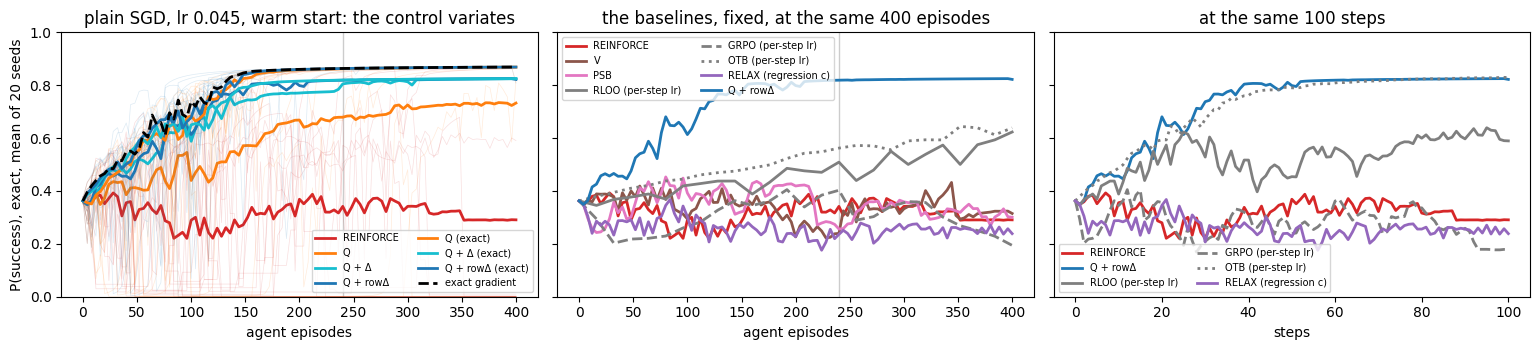

lr 0.045, warm start, 20 seeds             solves  collapses   mean over the run           final  episodes to 0.8 (solving runs)
  REINFORCE                    7         13        0.319 +-0.054    0.291 +-0.091                  193  (132-304)
  RLOO                         0         20        0.038 +-0.005    0.000 +-0.000                               -
  GRPO                         0         20        0.022 +-0.002    0.000 +-0.000                               -
  OTB                          0         17        0.125 +-0.021    0.068 +-0.041                               -
  RELAX                        7         14        0.175 +-0.036    0.213 +-0.077                  283  (232-400)
  V                           12         11        0.339 +-0.043    0.315 +-0.081                  272  (108-384)
  PSB                         12         13        0.349 +-0.056    0.300 +-0.094                  169  (108-336)
  Q                           17          3        0.599 +-0.056    0.732

In [ ]:
import glob
MID, FIX = "_sgd_long/warm_lr0.045", "_sgd_long/warm_lr0.045_fix"        # FIX (`_sgd_long/worker_fix.py`): RLOO/GRPO/OTB with the same lr per STEP and the same 100 steps (so 1600 episodes); RELAX with a surrogate that starts at 0 and is fitted by regression
tag = lambda m: m.replace(" ", "").replace("+", "p").replace("(", "").replace(")", "")
load = lambda d, m: np.stack([np.load(f) for f in sorted(glob.glob(f"{d}/{tag(m)}_s*.npy"))])
mid = {m: load(MID, m) for m in SGD_METHODS}                                                # every method, 20 seeds, lr x K per step for the group methods (as above)
FIXED = {"RLOO": "RLOO (per-step lr)", "GRPO": "GRPO (per-step lr)", "OTB": "OTB (per-step lr)", "RELAX": "RELAX (regression c)"}
fix = {FIXED[m]: load(FIX, m) for m in FIXED}
n_seeds = len(mid["Q"]); at = lambda L, ep: L[:, np.searchsorted(L[0, :, 0], ep), 1]         # P(success) of every seed at an episode count

fig, ax = plt.subplots(1, 3, figsize=(15.5, 3.6), sharey=True)
for a, ms in zip(ax[:2], (["REINFORCE", "Q", "Q + Δ", "Q + rowΔ", "Q (exact)", "Q + Δ (exact)", "Q + rowΔ (exact)", "exact gradient"], ["REINFORCE", "V", "PSB"] + list(FIXED.values()) + ["Q + rowΔ"])):
    for m in ms:
        L = mid[m] if m in mid else fix[m]; L = L[:, L[0, :, 0] <= 400]                                        # the first 400 episodes
        col, ls = style[m.split(" (")[0]]; a.plot(L[0, :, 0], L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=m)
        if a is ax[0] and m in ("REINFORCE", "Q", "Q + rowΔ"):
            for run in L: a.plot(run[:, 0], run[:, 1], color=col, ls=ls, lw=0.5, alpha=0.15)
    a.set(xlabel="agent episodes", ylim=(0, 1)); a.legend(fontsize=7, ncol=2); a.axvline(4 * STEPS, color="0.8", lw=1, zorder=0)
for m in ["REINFORCE", "Q + rowΔ"] + list(FIXED.values()):                                  # the same number of steps: the group methods get 4 episodes per step
    L = mid[m] if m in mid else fix[m]; col, ls = style[m.split(" (")[0]]; ax[2].plot(np.arange(L.shape[1]), L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=m)
ax[2].set(xlabel="steps", ylim=(0, 1)); ax[2].legend(fontsize=7, ncol=2)
ax[0].set(ylabel=f"P(success), exact, mean of {n_seeds} seeds", title="plain SGD, lr 0.045, warm start: the control variates"); ax[1].set(title="the baselines, fixed, at the same 400 episodes"); ax[2].set(title="at the same 100 steps")
plt.tight_layout(); plt.show()

print(f"lr 0.045, warm start, {n_seeds} seeds{'':<11}{'solves':>8}{'collapses':>11}{'mean over the run':>20}{'final':>16}{'episodes to 0.8 (solving runs)':>32}")
rows = {**mid, **fix}
for m, L in rows.items():
    fin = L[:, -1, 1]; mean = L[:, :, 1].mean(1); hit = [int(run[np.argmax(run[:, 1] >= 0.8), 0]) for run in L if (run[:, 1] >= 0.8).any()]
    note = f"  [{int(L[0, -1, 0])} episodes; over the first 400: mean {L[:, L[0, :, 0] <= 400, 1].mean():.3f}, at 400: {at(L, 400).mean():.3f}]" if L[0, -1, 0] > 400 else ""
    print(f"  {m:<22}{len(hit):>8}{int((fin < 0.05).sum()):>11}{mean.mean():>13.3f} +-{mean.std(ddof=1) / len(mean) ** 0.5:.3f}{fin.mean():>9.3f} +-{fin.std(ddof=1) / len(fin) ** 0.5:.3f}"
          f"{(f'{np.mean(hit):.0f}  ({min(hit)}-{max(hit)})' if hit else '-'):>32}{note}")
print("paired over the seeds, mean over the same 400 episodes (the group methods' first 25 steps):")
m400 = lambda L: L[:, L[0, :, 0] <= 400, 1].mean(1)
for a, b in [("Q", "REINFORCE"), ("Q + rowΔ", "REINFORCE"), ("Q + rowΔ", "Q"), ("Q + rowΔ", "Q + Δ"), ("Q + Δ", "Q"), ("Q", "PSB"), ("Q", "RELAX (regression c)"), ("Q", "RLOO (per-step lr)"), ("Q", "OTB (per-step lr)"), ("Q + rowΔ", "RLOO (per-step lr)"), ("Q + rowΔ", "OTB (per-step lr)"),
             ("PSB", "REINFORCE"), ("V", "REINFORCE"), ("RELAX (regression c)", "REINFORCE"), ("RELAX (regression c)", "RELAX"), ("RLOO (per-step lr)", "REINFORCE"), ("OTB (per-step lr)", "REINFORCE"), ("GRPO (per-step lr)", "REINFORCE"),
             ("Q + rowΔ (exact)", "Q (exact)"), ("Q + rowΔ (exact)", "Q + Δ (exact)")]:
    x, y = m400(rows[a]), m400(rows[b]); d = x - y
    print(f"    {a:<22} - {b:<22} {d.mean():+.3f} +- {d.std(ddof=1) / len(d) ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.4f}   {int((d > 0).sum())}/{len(d)} seeds")
print("paired at the same 100 steps (mean over the run):")
for a, b in [("RLOO (per-step lr)", "REINFORCE"), ("OTB (per-step lr)", "REINFORCE"), ("GRPO (per-step lr)", "REINFORCE"), ("Q", "RLOO (per-step lr)"), ("Q + rowΔ", "RLOO (per-step lr)"), ("Q", "OTB (per-step lr)"), ("Q + rowΔ", "OTB (per-step lr)")]:
    x, y = rows[a][:, :, 1].mean(1), rows[b][:, :, 1].mean(1); d = x - y
    print(f"    {a:<22} - {b:<22} {d.mean():+.3f} +- {d.std(ddof=1) / len(d) ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.4f}   {int((d > 0).sum())}/{len(d)} seeds")


**At lr 0.045 the order is the one the residual is meant to produce, and 20 seeds carry it.**  Mean over the same 400
episodes: Q + rowΔ 0.729 ≈ Q + Δ 0.714 > Q 0.599 > OTB 0.516 ≈ RLOO 0.464 (per-step lr) > PSB 0.349 ≈ V 0.339 ≈ REINFORCE
0.319 ≈ GRPO 0.304 ≈ RELAX 0.260 (regression c).  Paired over the seeds: Q + rowΔ − Q +0.131 ± 0.053 (p 0.02, 17 of 20);
Q − RLOO +0.135 (p 0.03) and Q − OTB +0.082 (p 0.15); RLOO − REINFORCE +0.146 (p 0.016) and OTB − REINFORCE +0.198 (p 0.001);
Q + rowΔ − REINFORCE +0.411 (20 of 20).  The two residuals are not separated (+0.016 ± 0.016).

**What the fixes did.**  With the step scaled by K, RLOO, GRPO and OTB collapsed on 17-20 seeds of 20 and sat below REINFORCE
(0.04-0.13).  With the same step as everyone else RLOO passes 0.8 on 18 seeds and collapses on 5 (0.464 over the first 400
episodes, 0.527 over its 100 steps), and OTB converges on all 20 (0.516 / 0.721), to its own plateau of 0.83 rather than
0.87, the bias cell 15 describes.  Given the same 100 steps, and so four times the episodes, OTB is ahead of Q (−0.122, p 0.04)
and ties Q + rowΔ (+0.009); at the same episodes it is behind both.  GRPO does not recover (15 collapses, 0.304 ≈ REINFORCE):
dividing by the group std keeps its advantages at ±1-1.7 whatever the policy's state, so its steps never shrink.  RELAX with
the regression surrogate gains +0.085 over its variance-fitted version (p 0.14) and ends level with REINFORCE (−0.058, p 0.45):
the early noise is gone, but the estimator still turns every failed episode into a step, and 13 of 20 runs collapse as
REINFORCE's do.  The mean baselines V and PSB tie with REINFORCE for the same reason.

Where the residual's gap comes from.  Q collapses on 3 seeds of 20, the residuals on 1, and among the runs that converge the
residuals are faster (120-131 episodes to 0.8 against 161).  With the true table nobody collapses and the residual is worth
+0.010 (p 0.006) over Q (exact): the geometry alone buys little here.  The residual earns its keep on the fitted table, where
Q's own noise is larger and the run is closer to the edge.

So across the three rates: 0.03 separates nothing but speed, 0.045 separates residual > table > group baseline > none, and
0.06 collapses everyone, where the order is noise (over 20 seeds Q + rowΔ 0.544 and Q 0.528 are tied).  The residual moves
the edge, and that shows as an order only in the window where Q is at its edge and the residuals are not yet at theirs.


### Warm start with Adam

The same warm starts under the notebook's Adam setting (lr 1e-3), 400 episodes, seeds 0-19, all fourteen methods; the group
baselines at the same episode budget, 25 steps of four episodes per task, as in the Adam runs above.  The last column of the
table is the cold-start Adam run above, its final value at 240 episodes.


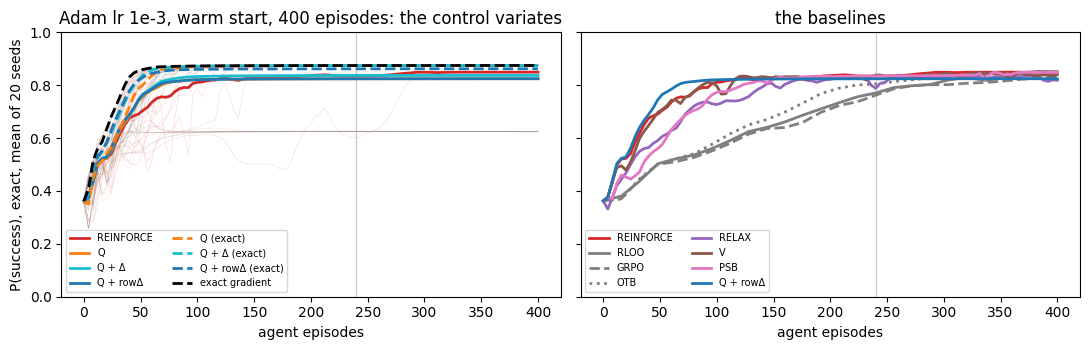

Adam 1e-3, warm start, 20 seeds          solves  collapses   mean over the run  at 240 ep           final  episodes to 0.8 (solving runs)  cold start, final at 240
  REINFORCE              18          0        0.792 +-0.016      0.834    0.849 +-0.017                    80  (40-284)                     0.845
  RLOO                   19          0        0.681 +-0.013      0.771    0.851 +-0.005                  240  (160-352)                     0.635
  GRPO                   18          0        0.670 +-0.014      0.762    0.834 +-0.017                  246  (176-368)                     0.605
  OTB                    19          0        0.700 +-0.010      0.805    0.839 +-0.013                  209  (160-288)                     0.583
  RELAX                  17          0        0.756 +-0.018      0.788    0.819 +-0.025                    92  (40-168)                     0.638
  V                      19          0        0.785 +-0.011      0.838    0.840 +-0.014                   

In [ ]:
import glob
ADAM = "_sgd_long/warm_adam"                                   # `SGD_OPT=adam SGD_FIXED_STEPS=100 SGD_WARM=_sgd_long/warm SGD_SEEDS=0-20 SGD_JOBS="0.001:<dir>" python _sgd_long/worker.py <gpu>`: Adam lr 1e-3, 400 episodes, seeds 0-4 warm starts
tag = lambda m: m.replace(" ", "").replace("+", "p").replace("(", "").replace(")", "")
adam = {m: np.stack([np.load(f) for f in sorted(glob.glob(f"{ADAM}/{tag(m)}_s*.npy"))]) for m in SGD_METHODS}
n_seeds = len(adam["Q"]); at = lambda L, ep: L[:, np.searchsorted(L[0, :, 0], ep), 1]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for a, ms in zip(ax, (["REINFORCE", "Q", "Q + Δ", "Q + rowΔ", "Q (exact)", "Q + Δ (exact)", "Q + rowΔ (exact)", "exact gradient"], ["REINFORCE", "RLOO", "GRPO", "OTB", "RELAX", "V", "PSB", "Q + rowΔ"])):
    for m in ms:
        col, ls = style[m]; L = adam[m]; a.plot(L[0, :, 0], L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=m)
        if a is ax[0] and m in ("REINFORCE", "Q", "Q + rowΔ"):
            for run in L: a.plot(run[:, 0], run[:, 1], color=col, ls=ls, lw=0.5, alpha=0.15)
    a.set(xlabel="agent episodes", ylim=(0, 1)); a.legend(fontsize=7, ncol=2); a.axvline(4 * STEPS, color="0.8", lw=1, zorder=0)
ax[0].set(ylabel=f"P(success), exact, mean of {n_seeds} seeds", title="Adam lr 1e-3, warm start, 400 episodes: the control variates"); ax[1].set(title="the baselines")
plt.tight_layout(); plt.show()

print(f"Adam 1e-3, warm start, {n_seeds} seeds{'':<8}{'solves':>8}{'collapses':>11}{'mean over the run':>20}{'at 240 ep':>11}{'final':>16}{'episodes to 0.8 (solving runs)':>32}{'cold start, final at 240':>26}")
for m in SGD_METHODS:
    L = adam[m]; fin = L[:, -1, 1]; mean = L[:, :, 1].mean(1); hit = [int(run[np.argmax(run[:, 1] >= 0.8), 0]) for run in L if (run[:, 1] >= 0.8).any()]
    cold = logs[m][:, -1, 1].mean() if m in logs else float("nan")                     # the cold-start Adam runs above (60 steps = 240 episodes)
    print(f"  {m:<17}{len(hit):>8}{int((fin < 0.05).sum()):>11}{mean.mean():>13.3f} +-{mean.std(ddof=1) / len(mean) ** 0.5:.3f}{at(L, 240).mean():>11.3f}{fin.mean():>9.3f} +-{fin.std(ddof=1) / len(fin) ** 0.5:.3f}"
          f"{(f'{np.mean(hit):.0f}  ({min(hit)}-{max(hit)})' if hit else '-'):>32}{cold:>26.3f}")
print("paired over the seeds, mean over the run:")
for a, b in [("Q", "REINFORCE"), ("Q + rowΔ", "REINFORCE"), ("Q + rowΔ", "Q"), ("Q + rowΔ", "Q + Δ"), ("Q + Δ", "Q"), ("Q", "PSB"), ("Q", "RLOO"), ("Q", "RELAX"), ("PSB", "REINFORCE"), ("V", "REINFORCE"), ("RLOO", "REINFORCE"), ("OTB", "REINFORCE"), ("RELAX", "REINFORCE"), ("Q + rowΔ (exact)", "Q (exact)"), ("Q + rowΔ (exact)", "Q + Δ (exact)")]:
    x, y = adam[a][:, :, 1].mean(1), adam[b][:, :, 1].mean(1); d = x - y
    print(f"    {a:<18} - {b:<18} {d.mean():+.3f} +- {d.std(ddof=1) / len(d) ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.4f}   {int((d > 0).sum())}/{len(d)} seeds")


**Under Adam the estimators tie.**  Mean over the run: Q + Δ 0.798 ≈ REINFORCE 0.792 ≈ Q + rowΔ 0.788 ≈ Q 0.787 ≈ V 0.785 ≈
PSB 0.765 ≈ RELAX 0.756; no pair of these is separated (every p > 0.13), and nothing collapses.  The true table is worth
+0.04 (Q (exact) 0.833, the exact gradient 0.846), and the group methods lose 0.09-0.11 to REINFORCE (p ≤ 2e-4) because their
four-episode steps make the path four times shorter under Adam's normalised steps.  The residuals add nothing to Q here,
with either table.  What separates seeds is not the estimator: on seeds 7, 13 and 15 (and one more seed each) the Q family
ends at 0.625, one task of four unsolved, and REINFORCE on 7 and 15; those warm starts put one task on a confident wrong
answer that Adam at 1e-3 does not leave.

Against the cold start above (final at 240 episodes: REINFORCE 0.845, Q 0.814, Q + rowΔ 0.848) the warm start moves every
method to 0.82-0.85 by 240 episodes and removes the collapses, and the +0.05 the residual had over REINFORCE over the first
100 cold episodes is gone.  Adam's normalised steps make the noise irrelevant at this rate: the same null as the cold-start
Adam runs, one level up.  The estimators separate only where the step is proportional to the gradient, plain SGD, above.
